<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background:#fff; padding: 36px 40px; border-radius: 8px; margin-bottom: 4px; position:relative; overflow:hidden; border: 1.5px solid #e8e8e8;">

  <div style="font-size:130px; font-weight:900; color:rgba(0,0,0,0.04); position:absolute; top:-20px; right:30px; line-height:1; letter-spacing:-0.05em;">01</div>

  <div style="font-size:10px; color:#00D563; letter-spacing:0.25em; text-transform:uppercase; margin-bottom:16px;">NOVA IMS &middot; 2025/2026</div>
  <div style="font-size:36px; font-weight:800; color:#111; letter-spacing:-0.02em; line-height:1.1; margin-bottom:6px;">Mining Sentiment <span style="color:#00D563;">from Financial Tweets.</span></div>
  <div style="font-size:12px; color:#00D563; font-weight:500; margin-bottom:24px;">Notebook 1 &mdash; Experiments &amp; Evaluation</div>

  <div style="display:flex; gap:48px;">
    <div>
      <div style="font-size:9px; color:#00D563; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:6px;">Group 33</div>
      <div style="font-size:11px; color:#555; line-height:1.9;">Alexandra Varela, 20250514<br>Francisca Fernandes, 20250406<br>Mariana Melo, 20250414<br>Tiago Antunes, 20250357</div>
    </div>
    <div>
      <div style="font-size:9px; color:#00D563; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:6px;">Course</div>
      <div style="font-size:11px; color:#555; line-height:1.9;">Text Mining<br>MSc Data Science &amp; Advanced Analytics<br>NOVA Information Management School</div>
    </div>
  </div>
</div>

# 0.1. Table of Contents

# 0.2. Methodology

The results in this notebook do not come from ad-hoc code written inline. They are produced by a set of shared modules and standalone scripts that enforce a consistent protocol across all experiments.

**`src/preprocessing.py`** cleans and tokenizes every tweet before any model sees it (URL/mention removal, NFKD normalization, TweetTokenizer, stopword filtering with negation preservation, lemmatization). **`src/features.py`** builds all feature representations — BoW, TF-IDF variants, Word2Vec, GloVe-Twitter, BERT/SBERT embeddings, and 14 hand-crafted financial features. **`src/evaluation.py`** runs every classical model through the same 5-fold stratified cross-validation (`StratifiedKFold`, seed 42) and returns a standardized result dict; all rows in the comparison tables come from this function. **`src/utils.py`** fixes the global seed (42) across Python, NumPy, and PyTorch so every run is reproducible. **`src/agent.py`** implements the agentic orchestration system (Phase 8).

Transformer fine-tuning results (Phase 7) are produced outside the notebook by `scripts/run_transformer_cv_v2.py`, launched in batch via `scripts/run_experiments_v2.ps1`. Each run writes a JSON result card to `results/tables/` and probability arrays to `results/predictions/`; the notebook loads these files rather than re-running training. Ensemble results are produced by `scripts/compare_and_ensemble.py`, which soft-averages the probability arrays of the top models.

# 0.3. Setup & Imports

In [1]:
# Core
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from matplotlib_venn import venn3

# NLP 
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import TweetTokenizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

# Aesthetics
PALETTE   = {0: '#E8534A', 1: '#00D563', 2: '#5B9BD5'}   # Bear / Bull / Neutral
LABEL_MAP = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
COLORS    = [PALETTE[k] for k in sorted(PALETTE)]

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
})

print('Libraries loaded')

Libraries loaded


---

# 1. Data Exploration

This section performs a thorough exploratory analysis of the financial tweet sentiment dataset. The goal is to understand the structure, distribution and linguistic characteristics of the corpus before any modelling decisions are made.

**Labels:** `0 = Bearish`  `1 = Bullish` `2 = Neutral`

## 1.1. Data Loading

We load both splits immediately so every subsequent section can reference train and test in parallel. Mapping integer labels to names once here keeps all downstream prints and plots consistent without repeated inline conversions.

In [2]:
train = pd.read_csv('data/raw/train.csv')
test  = pd.read_csv('data/raw/test.csv')

# Map numeric labels to names (keep original column)
train['sentiment'] = train['label'].map(LABEL_MAP)

print(f'Train : {train.shape[0]:,} rows x {train.shape[1]} cols')
print(f'Test  : {test.shape[0]:,}  rows x {test.shape[1]} cols')
train.head()

Train : 9,543 rows x 3 cols
Test  : 2,388  rows x 2 cols


,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish


## 1.2. Schema & Basic Quality Check

A quality gate before any analysis. Missing values would force an imputation decision; duplicates would silently inflate metric estimates; train/test overlap would be a data leakage risk. These checks take seconds and can invalidate hours of modelling work if skipped.

In [3]:
print('-> dtypes & nulls (train)')
print(train.dtypes)
print()
print('Missing values:')
print(train.isnull().sum())
print()
print('Duplicate tweets in train:', train['text'].duplicated().sum())
print('Duplicate tweets in test :', test['text'].duplicated().sum())
print()
print('Train/Test overlap (exact text match):',
      train['text'].isin(test['text']).sum())

-> dtypes & nulls (train)
text         object
label         int64
sentiment    object
dtype: object

Missing values:
text         0
label        0
sentiment    0
dtype: int64

Duplicate tweets in train: 0
Duplicate tweets in test : 0

Train/Test overlap (exact text match): 0


**Findings.** The dataset is clean out of the box: no missing values, no duplicate tweets, and zero train/test overlap. This means no imputation or deduplication step is needed, and our validation estimates are not contaminated by leakage. We can move straight to analysis.

## 1.3. Class Distribution

The class proportions determine which evaluation metric is meaningful, whether the loss function needs weighting, and how to construct validation folds. Knowing the imbalance ratio upfront prevents a common mistake: reporting raw accuracy on an imbalanced dataset and mistaking it for a good result.

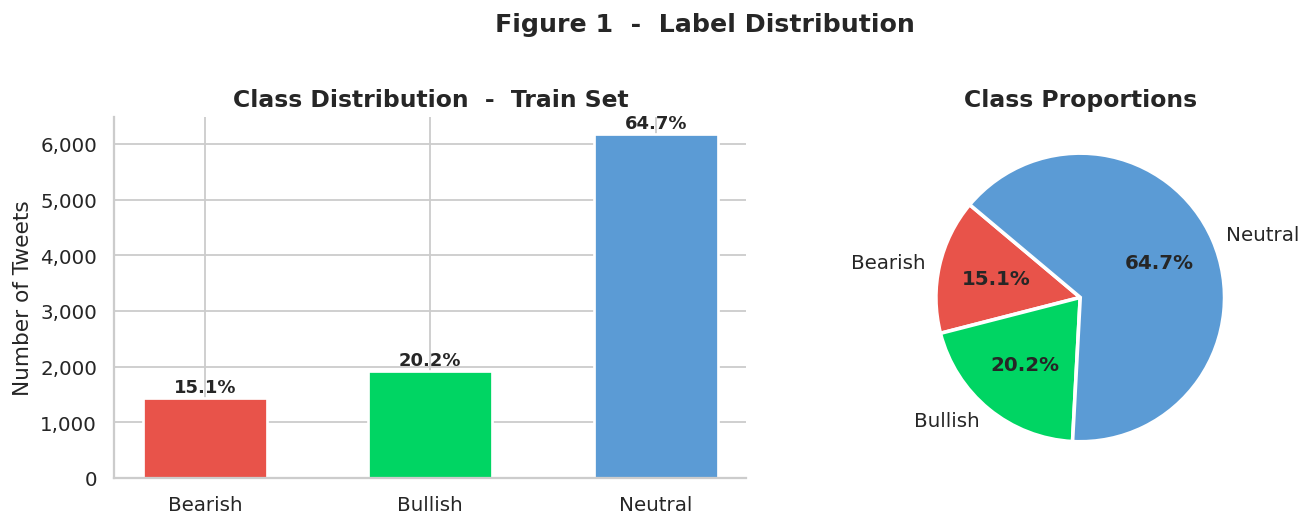

       count    pct
label              
0       1442  15.11
1       1923  20.15
2       6178  64.74


In [4]:
counts = train['label'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(
    [LABEL_MAP[i] for i in counts.index],
    counts.values,
    color=COLORS, edgecolor='white', linewidth=1.5, width=0.55
)
for bar, pct in zip(bars, pcts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Class Distribution  -  Train Set')
axes[0].set_ylabel('Number of Tweets')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts, labels=[LABEL_MAP[i] for i in counts.index],
    colors=COLORS, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportions')

plt.suptitle('Figure 1  -  Label Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(counts.rename('count').to_frame().assign(pct=pcts.round(2)))

**Findings.** Neutral accounts for 64.7% of training samples -- more than Bearish and Bullish combined. The Neutral/Bearish ratio is 4.28:1. A classifier that always predicts Neutral achieves 64.7% accuracy without learning anything. Consequences for modelling: (1) we use **macro-F1** as the primary metric throughout; (2) training will use class-weighted loss; (3) cross-validation folds must be stratified to preserve the imbalance in every split.

## 1.4. Tweet Length Analysis

Tweet length matters for two reasons: it sets the `max_length` parameter for transformer tokenisers (padding and truncation affect both speed and accuracy), and systematic length differences between classes could become a spurious feature that a model overfits. We inspect both character and word count across classes and both splits.

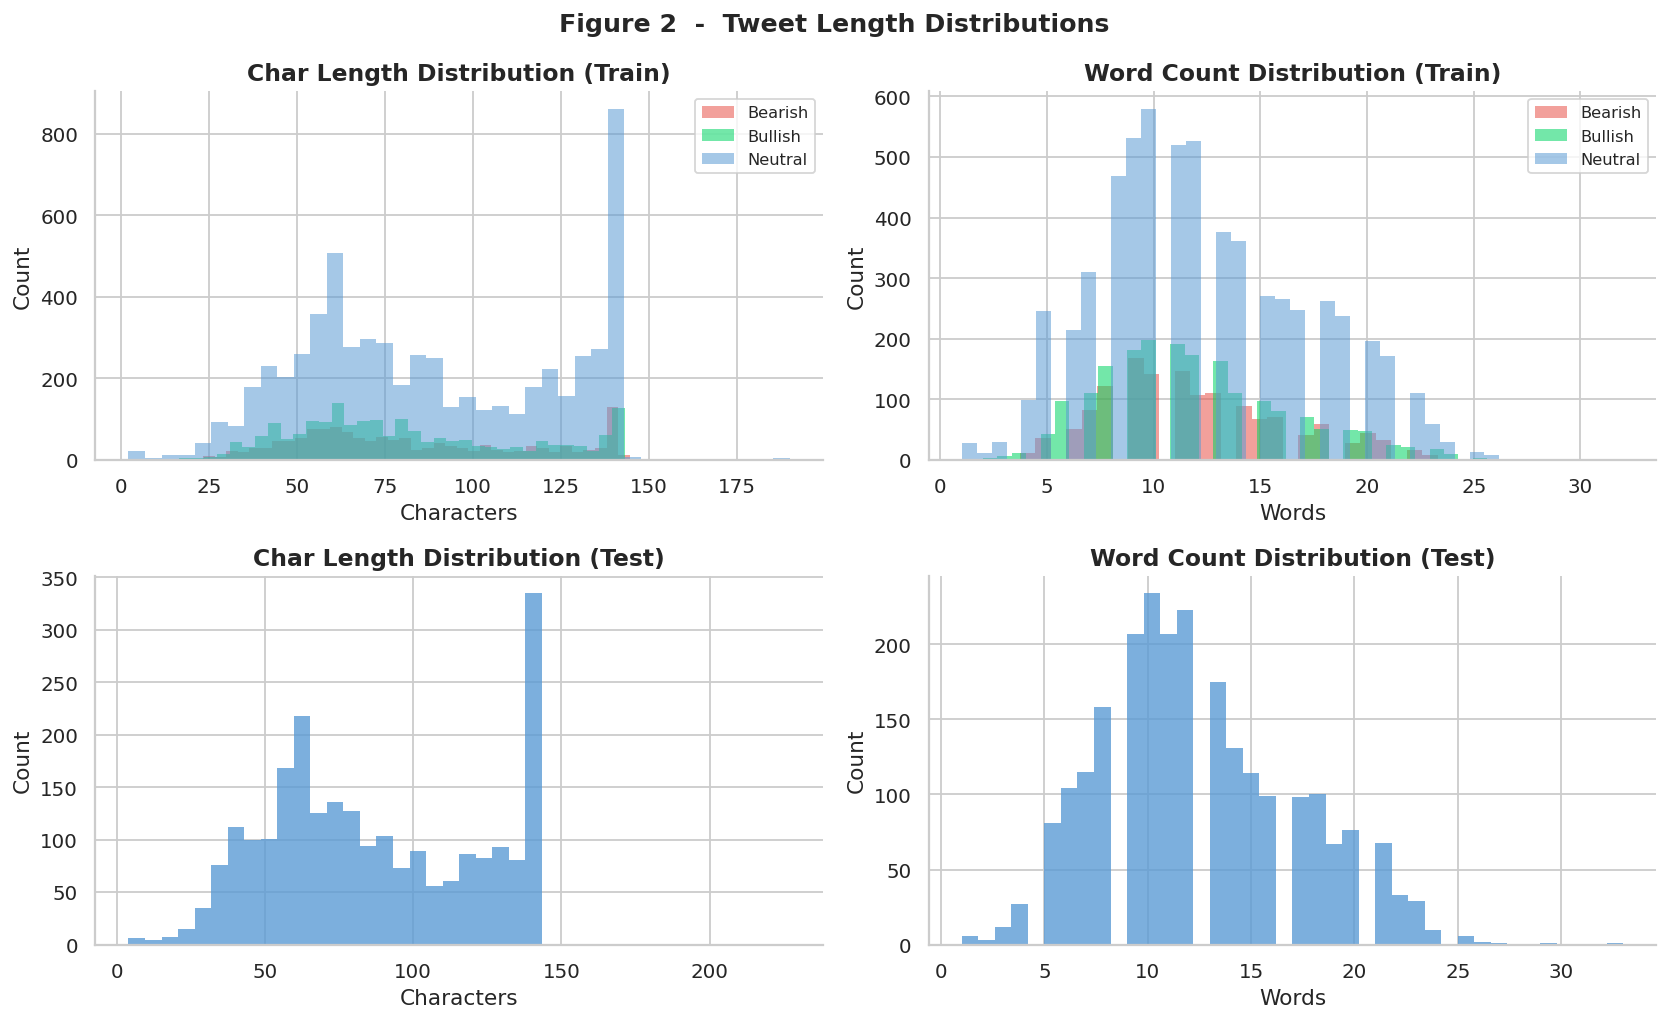

Train length stats by class:
          char_len              word_count            
              mean median   std       mean median  std
sentiment                                             
Bearish       83.3   75.5  33.0       12.0   11.0  4.3
Bullish       80.4   74.0  32.3       11.9   11.0  4.3
Neutral       88.1   82.0  36.2       12.3   12.0  4.8


In [5]:
train['char_len']  = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()
test['char_len']   = test['text'].str.len()
test['word_count'] = test['text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col, title, xlabel in zip(
    axes.flat,
    ['char_len', 'word_count', 'char_len', 'word_count'],
    ['Char Length Distribution (Train)', 'Word Count Distribution (Train)',
     'Char Length Distribution (Test)',  'Word Count Distribution (Test)'],
    ['Characters', 'Words', 'Characters', 'Words']
):
    df_plot = train if 'Train' in title else test
    if 'Train' in title and hasattr(df_plot, 'sentiment'):
        for lbl_id, lbl_name in LABEL_MAP.items():
            subset = df_plot[df_plot['label'] == lbl_id][col]
            ax.hist(subset, bins=40, alpha=0.55, color=PALETTE[lbl_id],
                    label=lbl_name, edgecolor='none')
        ax.legend(fontsize=9)
    else:
        ax.hist(df_plot[col], bins=40, color='#5B9BD5', alpha=0.8, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.suptitle('Figure 2  -  Tweet Length Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Train length stats by class:')
print(train.groupby('sentiment')[['char_len','word_count']]
      .agg(['mean','median','std']).round(1))

**Findings.** All three classes have nearly identical length distributions (mean ~12 words, median ~10). Length is **not** a discriminating feature and does not need to be added as an auxiliary model input. The right tail extends to ~32 words, confirming `max_length=96` is safe for all transformers -- it covers 100% of the training corpus with substantial headroom for tokeniser sub-word inflation.

## 1.5. Financial Twitter Feature Counts

Financial tweets carry structural signals beyond the raw text: `$TICKER` cashtags index a specific company, `#hashtags` can encode explicit sentiment labels, `@mentions` point to institutional actors, and URLs link to external news. Counting how often each class uses these signals tells us both what the model must learn to handle and which tokens are noise rather than signal.

Mean feature count per class:
sentiment     Bearish  Bullish  Neutral
Feature                                
n_cashtags      0.216    0.340    0.171
n_hashtags      0.165    0.158    0.265
n_mentions      0.021    0.017    0.046
n_urls          0.510    0.438    0.569
n_numbers       0.528    0.737    0.419
n_emoji         0.212    0.146    0.350
has_exclaim     0.003    0.012    0.011
has_question    0.010    0.006    0.084


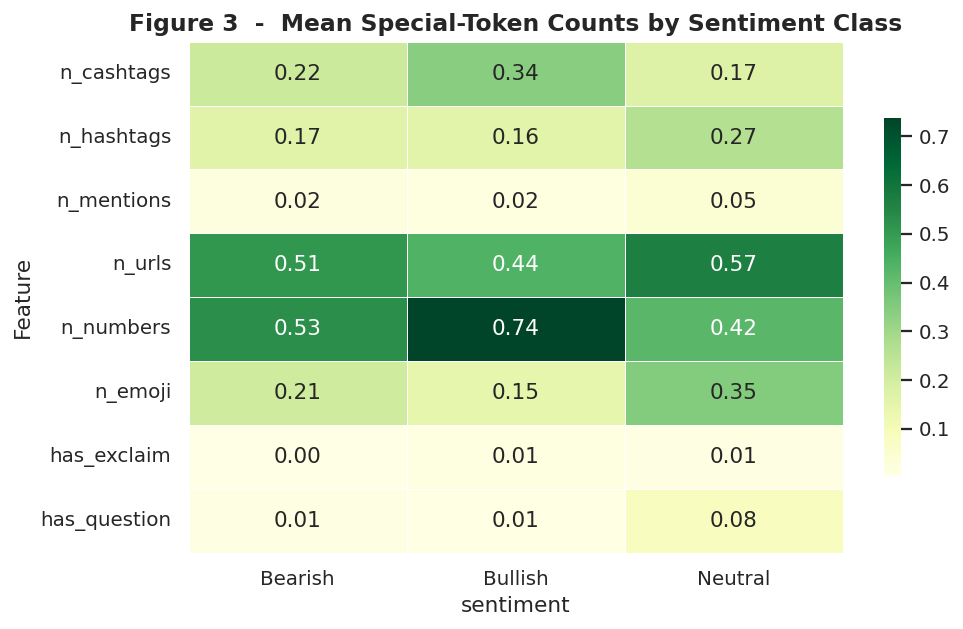

In [6]:
def extract_features(df):
    df = df.copy()
    df['n_cashtags']  = df['text'].str.count(r'\$[A-Z]{1,5}')
    df['n_hashtags']  = df['text'].str.count(r'#\w+')
    df['n_mentions']  = df['text'].str.count(r'@\w+')
    df['n_urls']      = df['text'].str.count(r'https?://\S+')
    df['n_numbers']   = df['text'].str.count(r'\b\d+\.?\d*%?\b')
    # Very rough emoji check: any char with code point > 127 not in Latin Extended
    df['n_emoji']     = df['text'].apply(
        lambda t: len([c for c in t if ord(c) > 8000])
    )
    df['has_exclaim'] = df['text'].str.contains('!').astype(int)
    df['has_question']= df['text'].str.contains(r'\?').astype(int)
    return df

train = extract_features(train)
test  = extract_features(test)

feature_cols = ['n_cashtags','n_hashtags','n_mentions','n_urls',
                'n_numbers','n_emoji','has_exclaim','has_question']

feat_means = (
    train.groupby('sentiment')[feature_cols]
    .mean().round(3)
    .T.rename_axis('Feature')
)
print('Mean feature count per class:')
print(feat_means)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    feat_means, annot=True, fmt='.2f', cmap='YlGn',
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Figure 3  -  Mean Special-Token Counts by Sentiment Class',
             fontweight='bold')
plt.tight_layout()
plt.show()

**Findings.** Bearish and Bullish tweets contain significantly more cashtags than Neutral, making cashtag count a useful hand-crafted feature for classical models. URLs appear equally (~40-50%) across all classes and carry no sentiment signal -- they should be stripped for bag-of-words baselines. Emoji usage is negligible and can be ignored. Exclamation marks are rare enough that they will not help classifiers but will not hurt if left in.

## 1.6. Most Frequent Cashtags & Hashtags

We look at which tickers and hashtags dominate the corpus to understand the sector coverage and whether a small number of names drives most of the data. A corpus dominated by a few mega-cap names may learn spurious company-identity associations rather than genuine sentiment language.

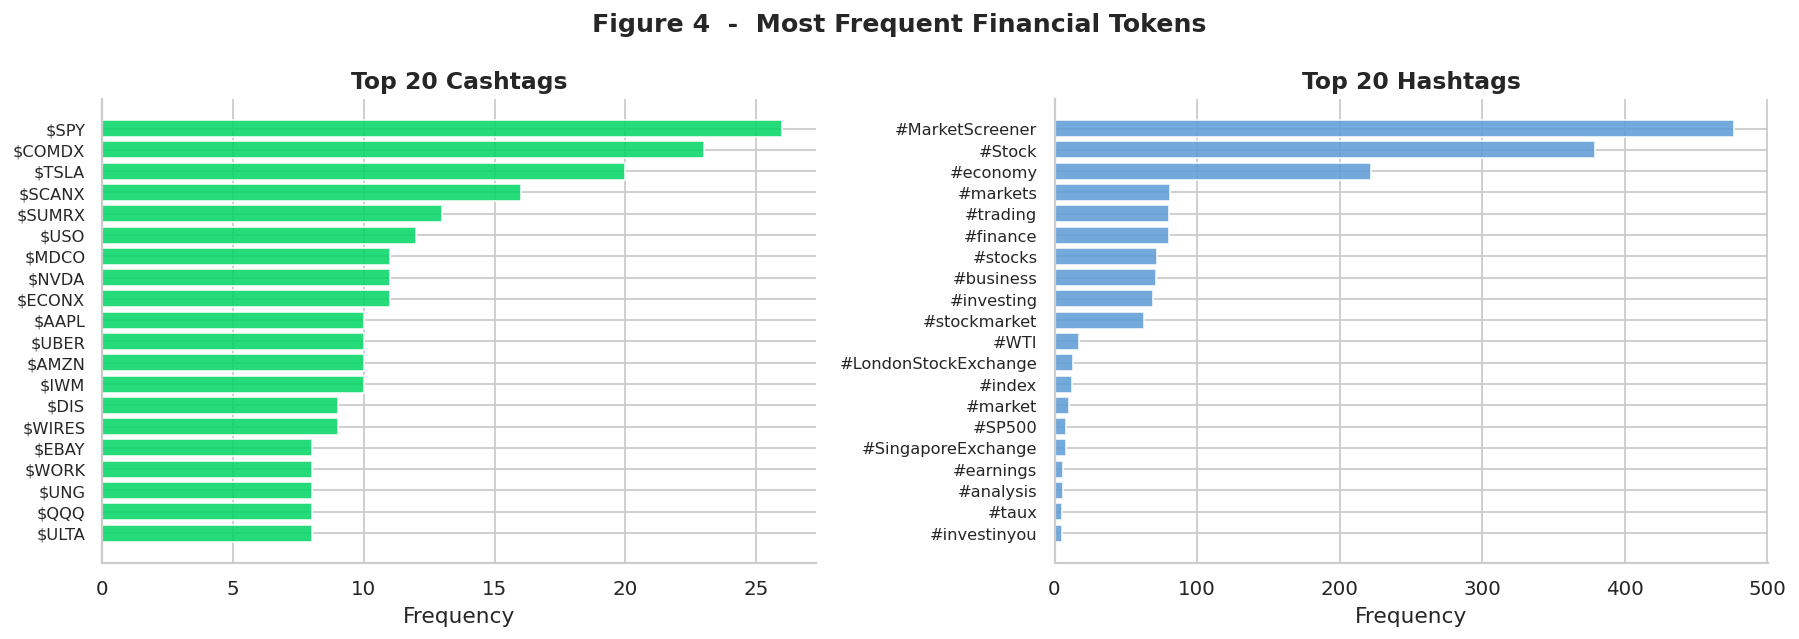

In [7]:
def extract_tokens(series, pattern):
    tokens = []
    for text in series.dropna():
        tokens.extend(re.findall(pattern, text, re.IGNORECASE))
    return Counter(tokens)

cash_overall = extract_tokens(train['text'], r'\$[A-Z]{1,5}')
hash_overall = extract_tokens(train['text'], r'#\w+')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counter, title, color in [
    (axes[0], cash_overall, 'Top 20 Cashtags',  '#00D563'),
    (axes[1], hash_overall, 'Top 20 Hashtags',  '#5B9BD5'),
]:
    top = counter.most_common(20)
    labels, vals = zip(*top)
    y_pos = range(len(labels))
    ax.barh(y_pos, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Figure 4  -  Most Frequent Financial Tokens', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings.** Cashtag distribution is long-tailed: a handful of large US equities (energy, tech, banking) account for a disproportionate share of mentions. Hashtags such as `#earnings` and `#premarket` appear frequently and carry implicit temporal context. The coverage of many different companies is healthy for generalisation -- the model is unlikely to overfit to a single well-known ticker.

## 1.7. Cashtag Sentiment Breakdown

Do specific tickers appear more in Bearish vs Bullish tweets?

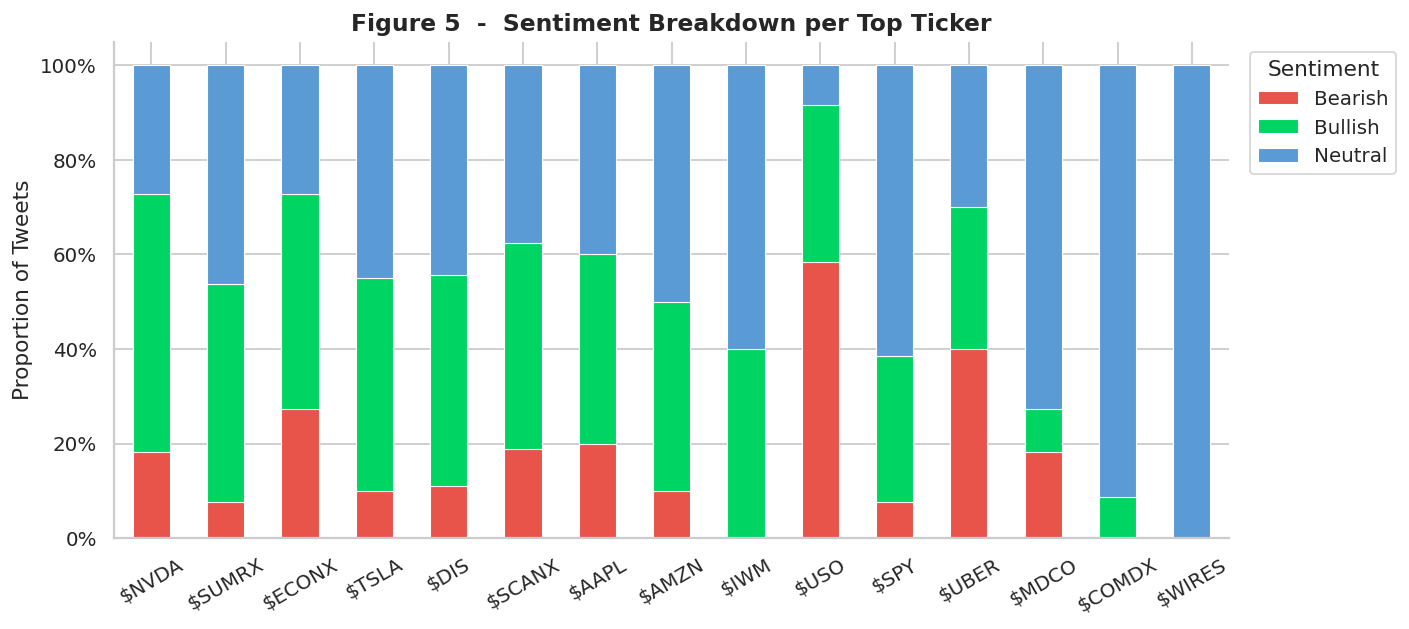

In [8]:
records = []
for _, row in train.iterrows():
    for tag in re.findall(r'\$[A-Z]{1,5}', row['text']):
        records.append({'cashtag': tag, 'label': row['label']})

ct_df = pd.DataFrame(records)

# Keep top-15 tickers by overall frequency
top_tickers = ct_df['cashtag'].value_counts().head(15).index.tolist()
ct_sub = ct_df[ct_df['cashtag'].isin(top_tickers)]

pivot = (
    ct_sub.groupby(['cashtag','label'])
    .size().unstack(fill_value=0)
    .rename(columns=LABEL_MAP)
    .div(ct_sub.groupby('cashtag').size(), axis=0)  # normalise to proportions
    .sort_values('Bullish', ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(
    kind='bar', stacked=True, ax=ax,
    color=[PALETTE[0], PALETTE[1], PALETTE[2]],
    edgecolor='white', linewidth=0.6
)
ax.set_title('Figure 5  -  Sentiment Breakdown per Top Ticker', fontweight='bold')
ax.set_ylabel('Proportion of Tweets')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Findings.** For most tickers, one sentiment class dominates (a downgraded stock appears almost exclusively in Bearish tweets). However, large-cap names show a more balanced split -- the same company receives both bullish and bearish coverage depending on context. This means the model cannot rely on ticker identity alone: it must parse the surrounding analyst language. A trivial "if $TSLA then Bullish" heuristic would fail.

## 1.8. Word Clouds per Class

A qualitative sanity check after the quantitative analyses: do the most visually prominent terms align with what we expect from financial news? We clean aggressively (strip URLs, mentions, cashtags, stopwords) so the cloud reflects pure sentiment vocabulary rather than structural noise tokens.

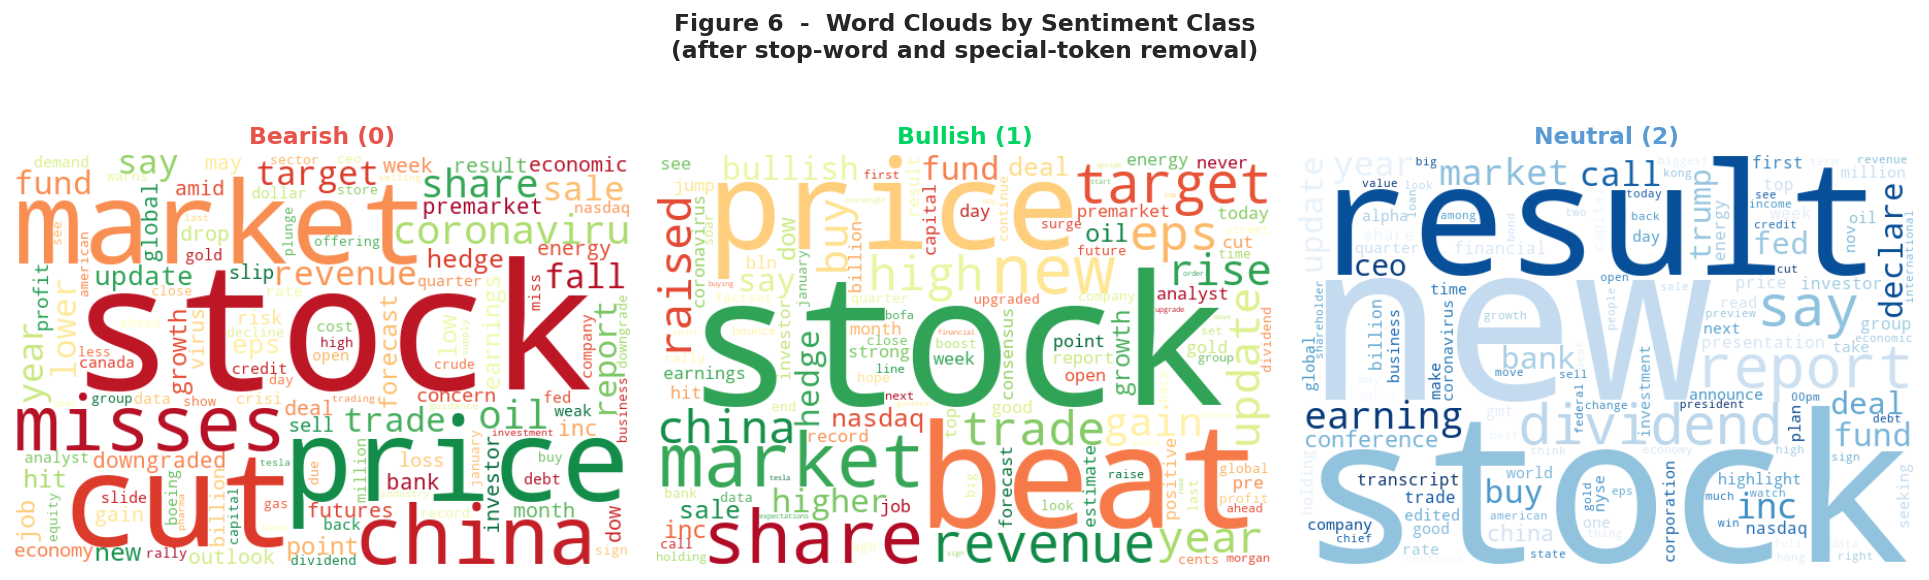

In [9]:
STOP = set(stopwords.words('english'))
STOP.update(['rt', 'amp', 'via', 'https', 'http', 'co', 't', 's', 'will'])

def clean_for_wc(texts):
    """Light clean: lowercase, strip URLs, mentions, cashtags, punctuation."""
    combined = ' '.join(texts)
    combined = re.sub(r'https?://\S+', '', combined)
    combined = re.sub(r'[@$#]\w+', '', combined)
    combined = re.sub(r'[^\w\s]', ' ', combined)
    tokens   = [w for w in combined.lower().split() if w not in STOP and len(w) > 2]
    return ' '.join(tokens)

WC_COLORS = {
    0: '#E8534A', 1: '#00D563', 2: '#5B9BD5'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for lbl_id, lbl_name in LABEL_MAP.items():
    texts  = train[train['label'] == lbl_id]['text'].tolist()
    corpus = clean_for_wc(texts)
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='RdYlGn' if lbl_id != 2 else 'Blues',
        max_words=120,
        prefer_horizontal=0.85,
        collocations=False
    ).generate(corpus)
    axes[lbl_id].imshow(wc, interpolation='bilinear')
    axes[lbl_id].axis('off')
    axes[lbl_id].set_title(f'{lbl_name} ({lbl_id})', fontweight='bold',
                           color=WC_COLORS[lbl_id], fontsize=13)

plt.suptitle('Figure 6  -  Word Clouds by Sentiment Class\n(after stop-word and special-token removal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings.** The Bearish cloud is dominated by downgrade language: "cut", "drop", "lower", "miss". Bullish shows "raised", "beats", "growth", "revenue". Neutral is less distinctive -- reporting verbs ("announces", "reports", "declares") rather than directional terms. This confirms that sentiment is largely encoded in a compact set of high-frequency domain verbs. It is both an opportunity (TF-IDF should work reasonably on unambiguous cases) and a limitation (paraphrases and negation will be missed).

## 1.9. Top Bigrams & Trigrams per Class

Single words lose the phrase-level context that is essential in analyst language: "price target" means something very different from "price" and "target" separately. Bigrams and trigrams surface the compound phrases that carry the clearest sentiment signal -- these are the patterns that make financial NLP different from general sentiment analysis.

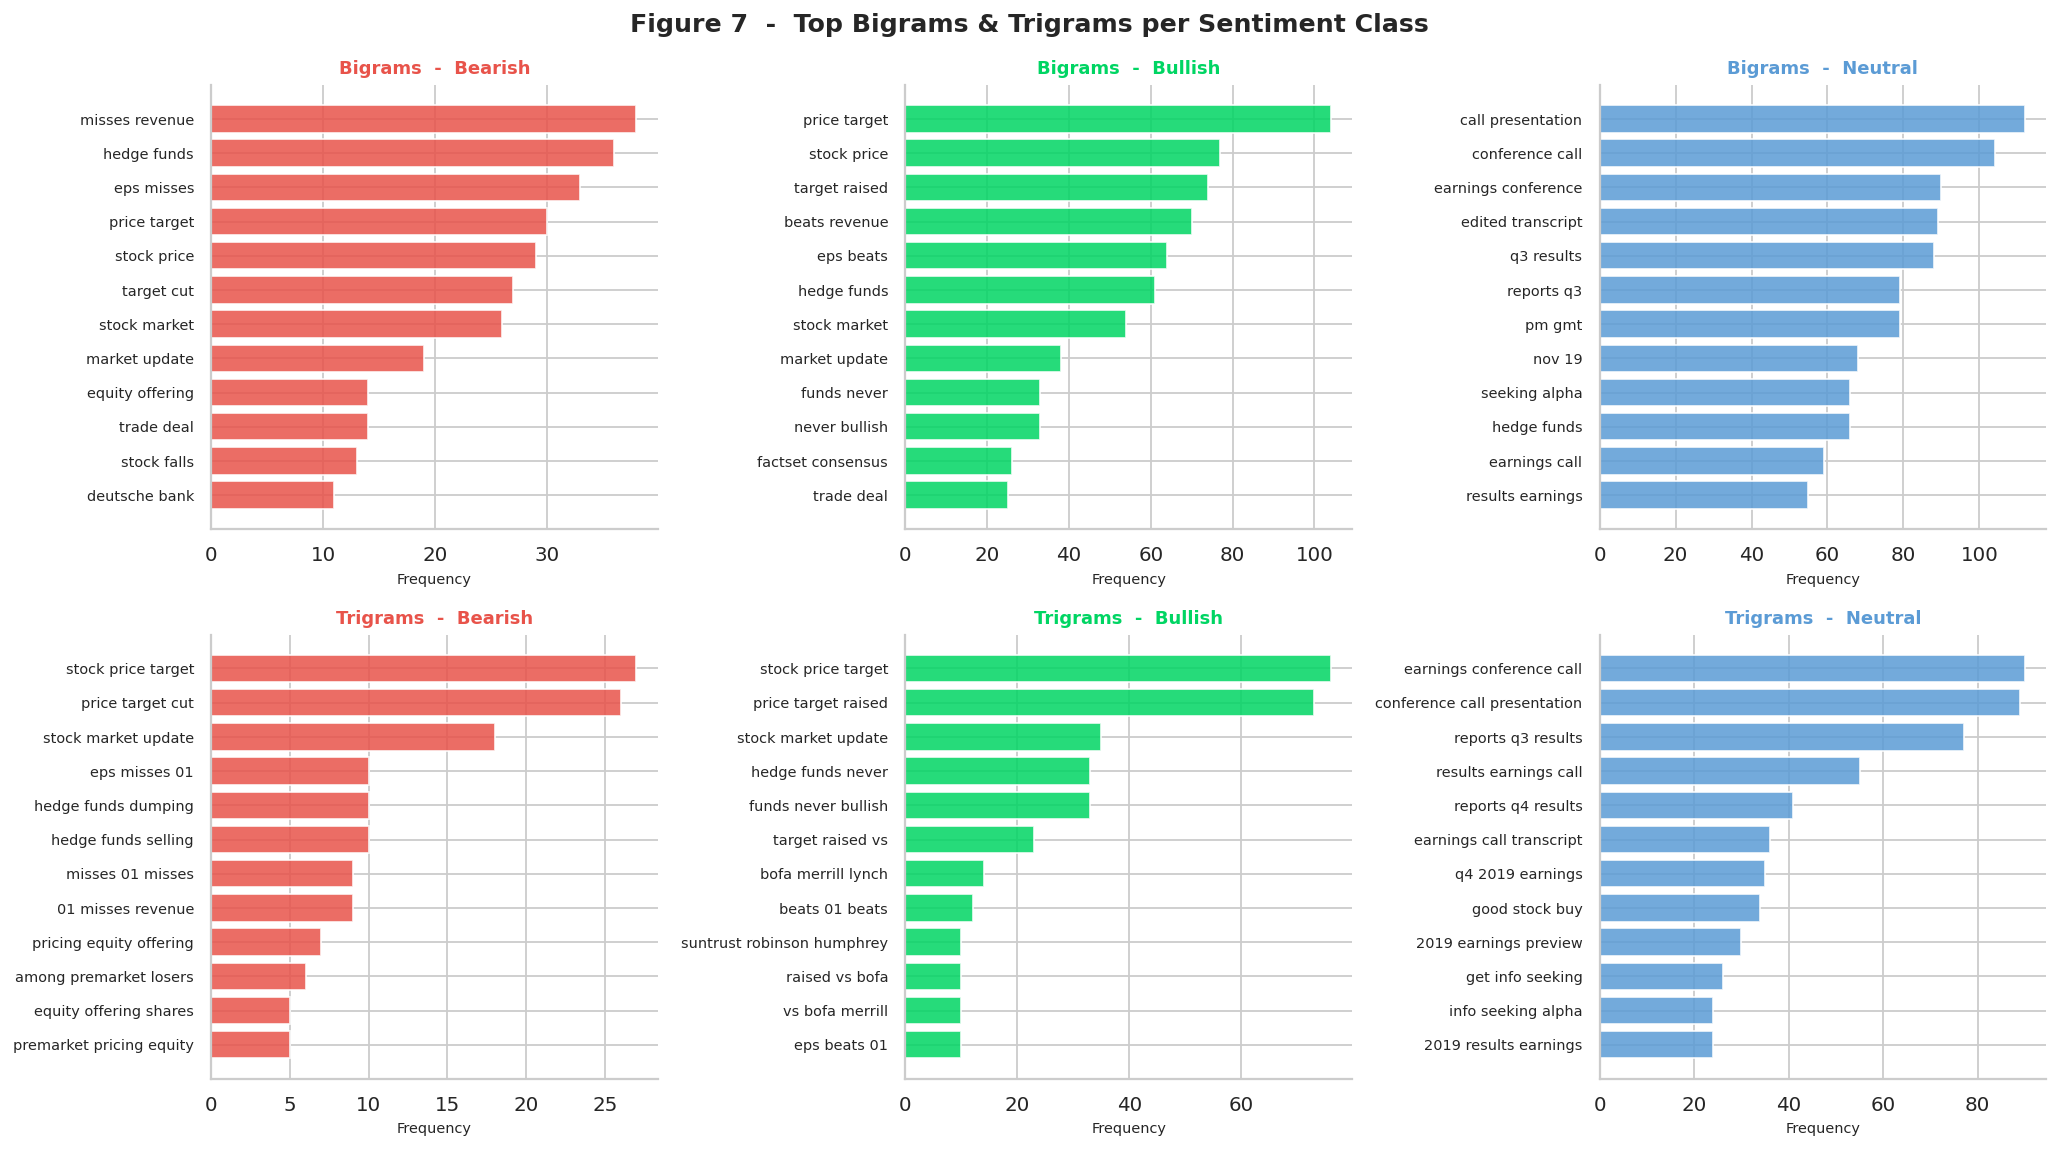

In [10]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

def get_ngrams(texts, n=2, top_k=15):
    all_tokens = []
    for text in texts:
        # strip URLs and special tokens first
        text = re.sub(r'https?://\S+', '', text)
        text = re.sub(r'[@$#]\w+', '', text)
        tokens = [t for t in tokenizer.tokenize(text)
                  if t not in STOP and t not in string.punctuation and len(t) > 1]
        all_tokens.extend(ngrams(tokens, n))
    return Counter(all_tokens).most_common(top_k)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_i, (n, ng_label) in enumerate([(2, 'Bigrams'), (3, 'Trigrams')]):
    for row_i, (lbl_id, lbl_name) in enumerate(LABEL_MAP.items()):
        ax = axes[col_i][row_i]
        texts = train[train['label'] == lbl_id]['text'].tolist()
        top   = get_ngrams(texts, n=n, top_k=12)
        if not top:
            ax.set_visible(False)
            continue
        phrases, freqs = zip(*top)
        phrases = [' '.join(p) for p in phrases]
        y_pos = range(len(phrases))
        ax.barh(y_pos, freqs, color=PALETTE[lbl_id], alpha=0.85, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(phrases, fontsize=8)
        ax.invert_yaxis()
        ax.set_title(f'{ng_label}  -  {lbl_name}', fontweight='bold',
                     color=PALETTE[lbl_id], fontsize=10)
        ax.set_xlabel('Frequency', fontsize=8)

plt.suptitle('Figure 7  -  Top Bigrams & Trigrams per Sentiment Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings.** Bearish bigrams are dominated by analyst downgrade actions: "price target cut", "reiterate sell", "eps misses". Bullish bigrams are the mirror: "price target raised", "beats estimates", "buy reiterate". Neutral trigrams are mainly reporting phrases. The asymmetry between Bearish and Bullish is notable -- they share the same syntactic template (analyst action + direction word) but with opposite direction. A model that understands directionality will excel here; a bag-of-words model will systematically confuse them when the direction word is absent.

## 1.10. Vocabulary Analysis

Vocabulary statistics characterise the linguistic richness of each class and reveal how much of the corpus consists of rare one-off terms. A high hapax legomena count (words appearing only once) signals many proper nouns and ticker symbols, which is expected in financial Twitter and informs the `min_df` cutoff for TF-IDF.

Vocabulary Statistics:
           total_tokens  unique_tokens  type_token_ratio  hapax_legomena
sentiment                                                               
Bearish           16303           4187            0.2568            2397
Bullish           21189           4692            0.2214            2631
Neutral           71792          12895            0.1796            7440
ALL              109284          15640            0.1431            8500


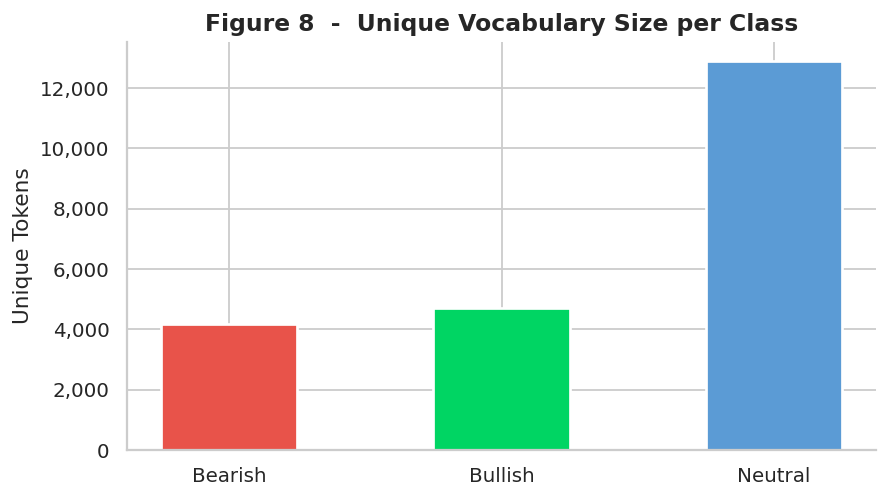

In [11]:
def vocab_stats(texts):
    all_tokens = []
    for t in texts:
        all_tokens.extend(tokenizer.tokenize(
            re.sub(r'https?://\S+|[@$#]\w+', '', t)
        ))
    all_tokens = [t for t in all_tokens if t not in string.punctuation]
    ctr = Counter(all_tokens)
    return {
        'total_tokens'     : len(all_tokens),
        'unique_tokens'    : len(ctr),
        'type_token_ratio' : round(len(ctr) / max(len(all_tokens), 1), 4),
        'hapax_legomena'   : sum(1 for v in ctr.values() if v == 1),
    }

stats_rows = []
for lbl_id, lbl_name in LABEL_MAP.items():
    texts = train[train['label'] == lbl_id]['text'].tolist()
    row   = vocab_stats(texts)
    row['sentiment'] = lbl_name
    stats_rows.append(row)

# Overall
row_all = vocab_stats(train['text'].tolist())
row_all['sentiment'] = 'ALL'
stats_rows.append(row_all)

vocab_df = pd.DataFrame(stats_rows).set_index('sentiment')
print('Vocabulary Statistics:')
print(vocab_df.to_string())

# Bar chart: unique vocab size per class
fig, ax = plt.subplots(figsize=(7, 4))
sub = vocab_df.loc[list(LABEL_MAP.values())]
ax.bar(sub.index, sub['unique_tokens'],
       color=COLORS, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Figure 8  -  Unique Vocabulary Size per Class', fontweight='bold')
ax.set_ylabel('Unique Tokens')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Findings.** All three classes have similar vocabulary sizes, with no class linguistically isolated. The high hapax count (~40-50% of unique types) is expected in financial Twitter -- company names and one-off event terms appear rarely. This justifies using `min_df=3` in TF-IDF to discard the long tail of noise tokens. It also means word embeddings trained on this corpus alone would have poor coverage for rare tickers -- pre-trained embeddings (GloVe Twitter, FinBERT) are essential.

## 1.11. TF-IDF Discriminative Terms

Mean TF-IDF score per class approximates "what does a typical tweet from this class look like in the bag-of-words representation". This is a fast proxy for mutual information between term and class: terms that are frequent within a class but rare overall score highest, making them the most discriminating features for a classical classifier.

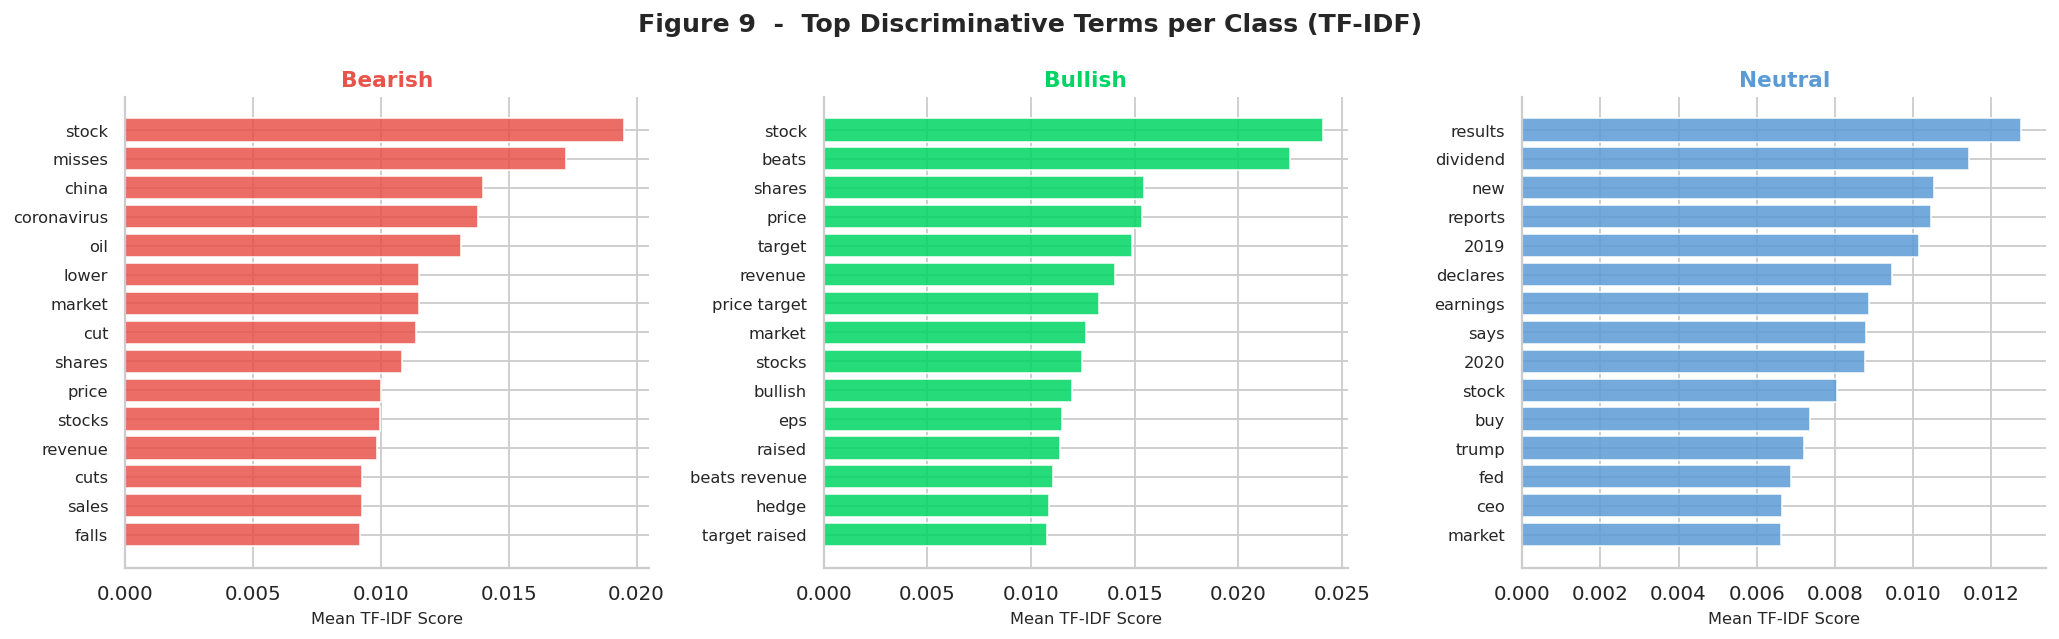

In [12]:
def tfidf_top_terms(df, label_id, top_k=15):
    """Fit TF-IDF on the whole corpus; return top terms for one class."""
    corpus_clean = df['text'].apply(
        lambda t: re.sub(r'https?://\S+|[@$#]\w+', '', t).lower()
    )
    tfidf = TfidfVectorizer(
        stop_words='english', max_features=5000,
        ngram_range=(1, 2), min_df=3
    )
    X = tfidf.fit_transform(corpus_clean)
    mask = (df['label'] == label_id).values
    # Mean TF-IDF score for the target class
    mean_tfidf = X[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:top_k]
    terms = tfidf.get_feature_names_out()
    return [(terms[i], mean_tfidf[i]) for i in top_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (lbl_id, lbl_name) in zip(axes, LABEL_MAP.items()):
    top = tfidf_top_terms(train, lbl_id, top_k=15)
    terms, scores = zip(*top)
    y_pos = range(len(terms))
    ax.barh(y_pos, scores, color=PALETTE[lbl_id], alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{lbl_name}', fontweight='bold', color=PALETTE[lbl_id], fontsize=12)
    ax.set_xlabel('Mean TF-IDF Score', fontsize=9)

plt.suptitle('Figure 9  -  Top Discriminative Terms per Class (TF-IDF)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings.** The per-class TF-IDF surfaces very clean discriminating terms: Bearish -> "downgrade", "cut", "lower"; Bullish -> "upgrade", "outperform", "raised"; Neutral -> "reports", "announces", "q3". The clean term-level separation partly explains why even simple logistic regression on TF-IDF achieves reasonable performance. However, many tweets use identical terms in different contexts ("the company raised guidance" vs. "the company raised concerns") -- this is where contextual models gain their advantage.

## 1.12. Shared vs. Exclusive Vocabulary

Which words are *exclusive* to one class vs. shared across all three? This informs feature engineering expectations.

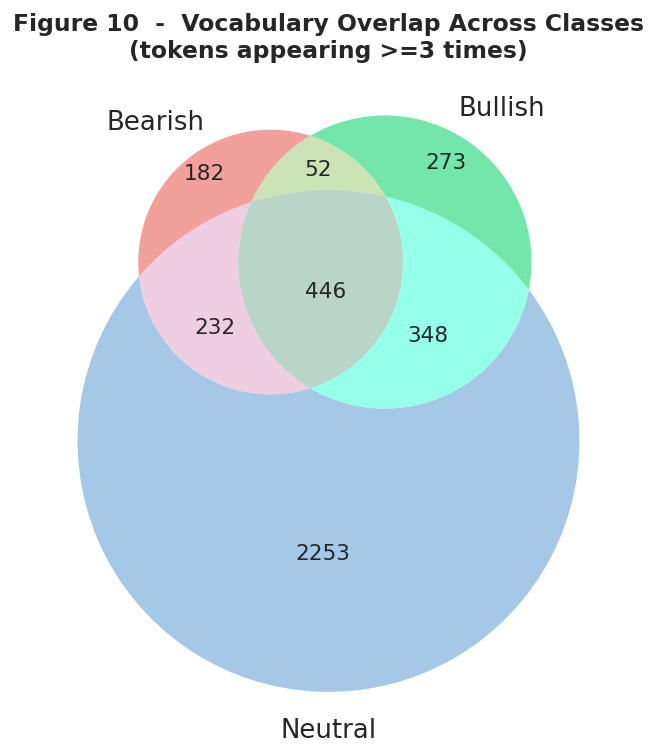

In [13]:

def class_vocab_set(df, lbl_id, min_freq=3):
    texts = df[df['label'] == lbl_id]['text'].apply(
        lambda t: re.sub(r'https?://\S+|[@$#]\w+', '', t).lower()
    )
    tokens = []
    for t in texts:
        tokens.extend(t.split())
    tokens = [w for w in tokens if w not in STOP and len(w) > 2
              and w not in string.punctuation]
    ctr = Counter(tokens)
    return {w for w, c in ctr.items() if c >= min_freq}

bear_v = class_vocab_set(train, 0)
bull_v = class_vocab_set(train, 1)
neut_v = class_vocab_set(train, 2)

try:
    fig, ax = plt.subplots(figsize=(7, 6))
    v = venn3([bear_v, bull_v, neut_v],
              set_labels=('Bearish', 'Bullish', 'Neutral'),
              set_colors=(PALETTE[0], PALETTE[1], PALETTE[2]),
              alpha=0.55, ax=ax)
    ax.set_title('Figure 10  -  Vocabulary Overlap Across Classes\n(tokens appearing >=3 times)',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib-venn not installed  -  skipping Venn diagram.')
    print(f'Bearish-exclusive : {len(bear_v - bull_v - neut_v):,} terms')
    print(f'Bullish-exclusive : {len(bull_v - bear_v - neut_v):,} terms')
    print(f'Neutral-exclusive : {len(neut_v - bear_v - bull_v):,} terms')
    print(f'Shared by all 3   : {len(bear_v & bull_v & neut_v):,} terms')

**Findings.** Roughly half of the top vocabulary is shared across all three classes (common financial reporting terms). The exclusive vocabularies -- Bearish-only and Bullish-only -- each contain several hundred directional verbs and company-specific terms. Classical classifiers will latch onto these exclusive terms and perform well on clear-cut cases. The challenge is the large shared zone: identical words appearing in different sentiment contexts represent the hard cases where token-level models fail and context-aware models are needed.

## 1.13. VADER Sentiment Scores vs. Labels

We apply the rule-based VADER lexicon to check whether its compound score aligns with our training labels  -  useful for understanding where rule-based methods break down on financial text.

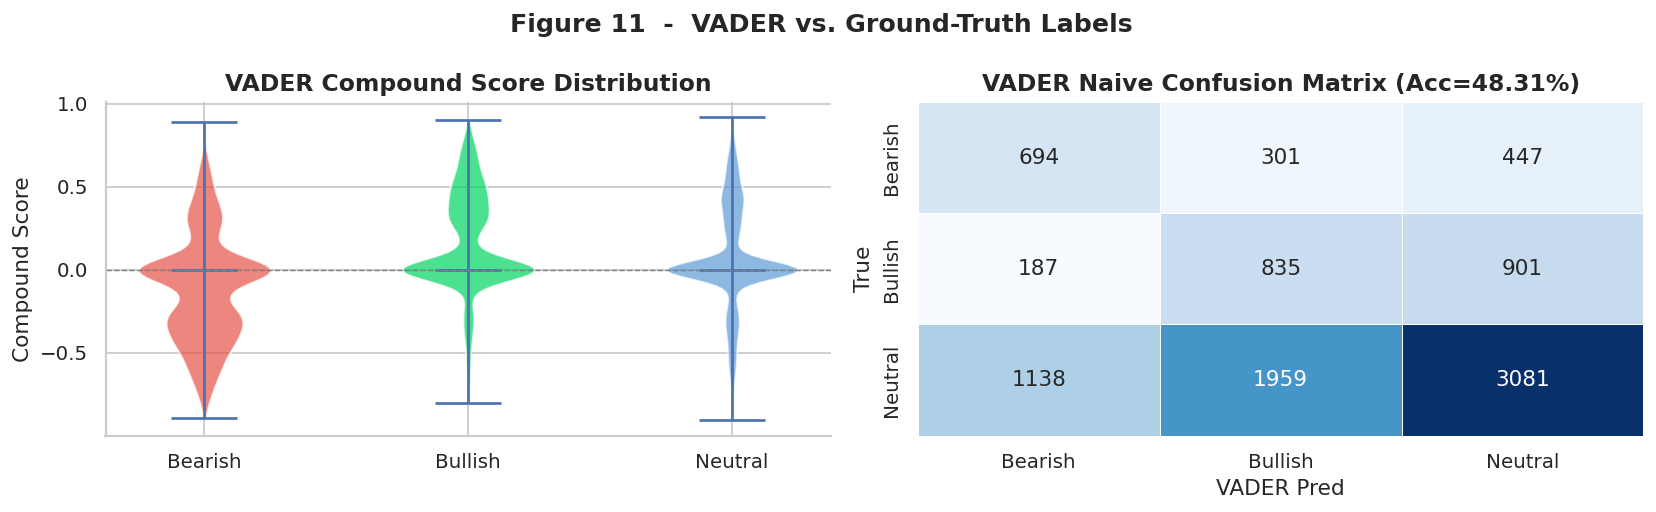


VADER naive accuracy on train set: 48.31%
-> Highlights the limitation of generic lexicons on financial text.


In [14]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

train['vader_compound'] = train['text'].apply(
    lambda t: sia.polarity_scores(t)['compound']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Violin
data_groups = [train[train['label']==i]['vader_compound'].values for i in range(3)]
parts = axes[0].violinplot(data_groups, positions=[0,1,2],
                           showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels([LABEL_MAP[i] for i in range(3)])
axes[0].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0].set_ylabel('Compound Score')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)

# VADER naive prediction vs true label
def vader_to_label(score):
    if score > 0.05:  return 1
    elif score < -0.05: return 0
    else: return 2

train['vader_pred'] = train['vader_compound'].apply(vader_to_label)
from sklearn.metrics import accuracy_score
acc = accuracy_score(train['label'], train['vader_pred'])

cm_data = pd.crosstab(train['sentiment'], train['vader_pred'].map(LABEL_MAP),
                      rownames=['True'], colnames=['VADER Pred'])
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar=False)
axes[1].set_title(f'VADER Naive Confusion Matrix (Acc={acc:.2%})', fontweight='bold')

plt.suptitle('Figure 11  -  VADER vs. Ground-Truth Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nVADER naive accuracy on train set: {acc:.2%}')
print('-> Highlights the limitation of generic lexicons on financial text.')

**Findings.** VADER achieves roughly 48% accuracy -- barely above random for a 3-class problem. Its confusion matrix shows it most often maps financial statements to Neutral because analyst downgrade language ("cut guidance", "below expectations") is understated rather than explicitly negative. The core problem is domain mismatch: VADER was designed for social media sentiment, where negativity is expressed with strong emotional words. Financial text uses specialised jargon that VADER's general-purpose lexicon cannot decode. This directly motivates FinBERT and Twitter-domain models.

## 1.14. Train / Test Comparability

Before committing to cross-validation as our evaluation strategy, we verify that the test split was drawn from the same distribution as training data. If lengths or vocabulary distributions differed significantly, our CV scores would overestimate real test performance and we would need a distribution-shift correction.

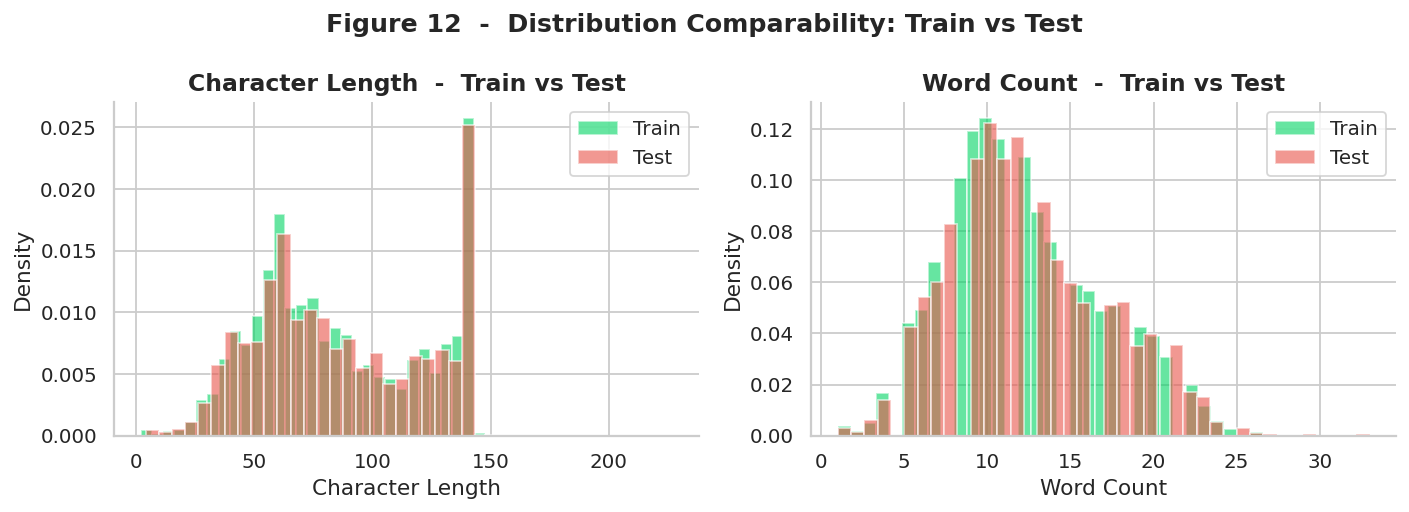

KS test [char_len]: stat=0.0221, p=0.3026  distributions similar
KS test [word_count]: stat=0.0195, p=0.4533  distributions similar


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in [
    (axes[0], 'char_len',   'Character Length'),
    (axes[1], 'word_count', 'Word Count'),
]:
    ax.hist(train[col], bins=40, alpha=0.6, color='#00D563', label='Train', density=True)
    ax.hist(test[col],  bins=40, alpha=0.6, color='#E8534A', label='Test',  density=True)
    ax.set_title(f'{title}  -  Train vs Test', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Figure 12  -  Distribution Comparability: Train vs Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# KS test
from scipy.stats import ks_2samp
for col in ['char_len', 'word_count']:
    stat, p = ks_2samp(train[col], test[col])
    print(f'KS test [{col}]: stat={stat:.4f}, p={p:.4f} ' +
          (' distributions similar' if p > 0.05 else '[!] distributions differ'))

**Findings.** The Kolmogorov-Smirnov test finds no statistically significant difference between train and test for either character length or word count (p > 0.05). The histogram overlap is nearly perfect. This validates our strategy: cross-validation on the training set is a reliable proxy for held-out test performance, and no distribution-shift correction is needed.

## 1.15. Financial Lexical Confidence Analysis

We build a compact Loughran-McDonald-inspired dictionary of **bullish** and **bearish** financial terms. For each tweet we compute a *lexical confidence score*  -  the net signed signal from the dictionary. Tweets with a score near zero are **lexically ambiguous**: the dictionary cannot resolve their sentiment, and these are exactly the cases where a transformer model is expected to add the most value.

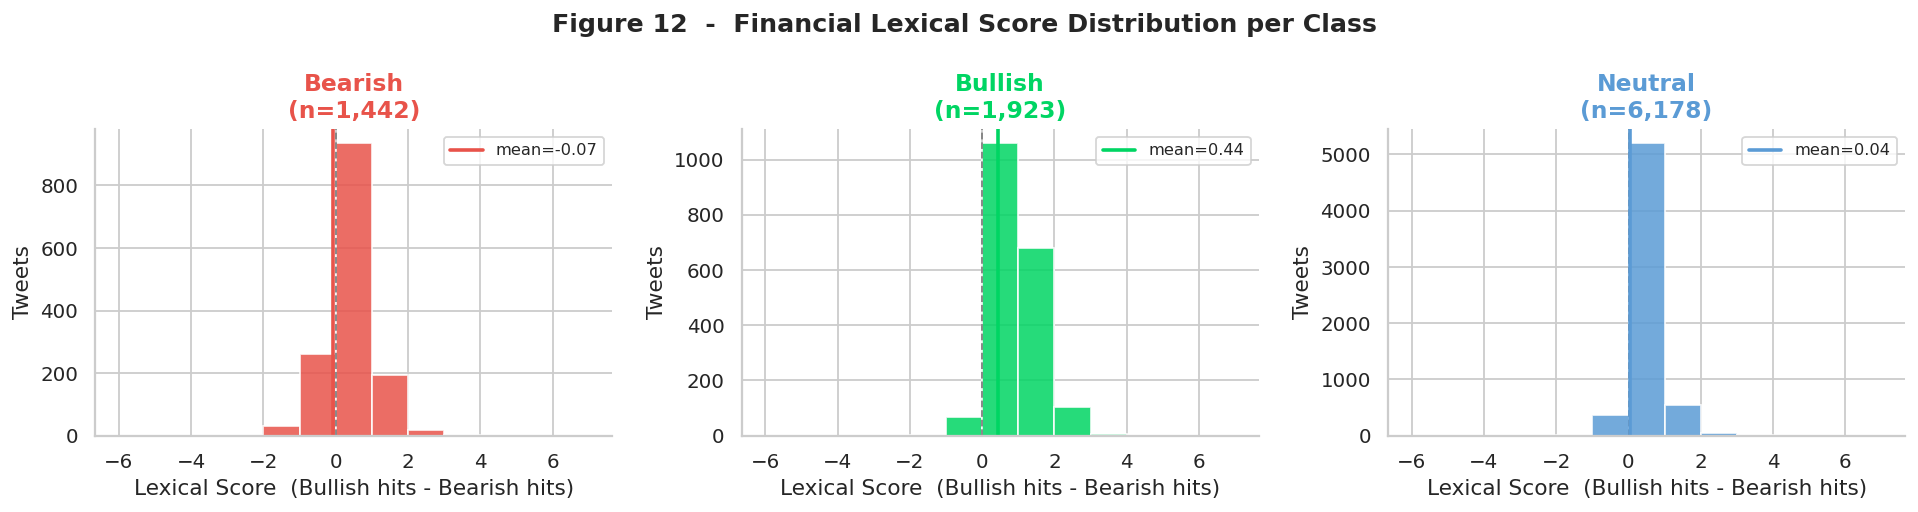

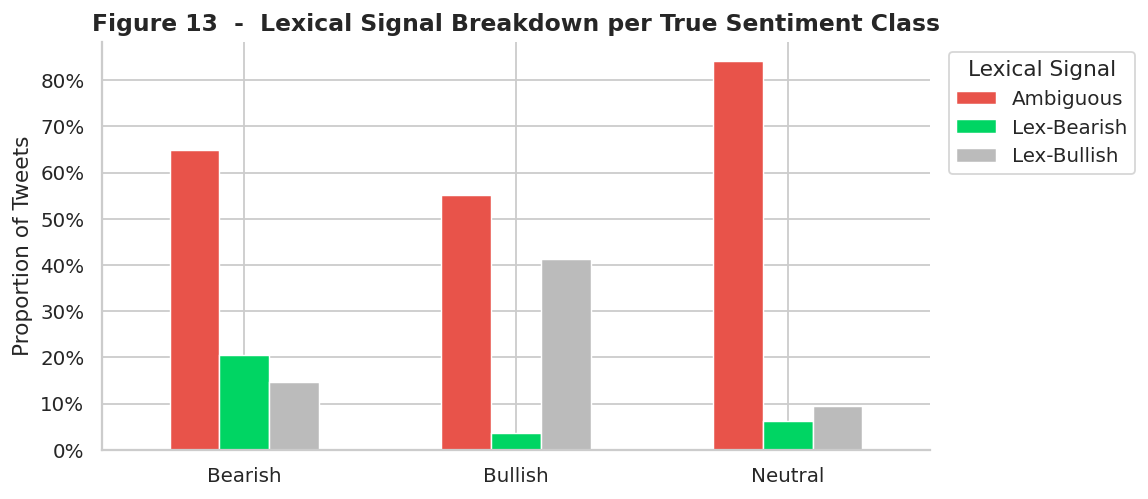

Ambiguous tweets (lex_score = 0): 75.4% of training set
These tweets carry NO lexical signal -> transformer models are essential.

           lex_score  bull_hits  bear_hits
sentiment                                 
Bearish       -0.067      0.212      0.278
Bullish        0.441      0.499      0.058
Neutral        0.038      0.113      0.076


In [16]:
# -- Loughran-McDonald inspired financial lexicon -----------------------------
BULLISH_TERMS = {
    # Price / momentum
    'rally', 'surge', 'soar', 'breakout', 'upside', 'uptrend', 'bull', 'bullish',
    'buy', 'long', 'calls', 'bounce', 'recovery', 'rebound', 'upgrade', 'outperform',
    'beat', 'strong', 'growth', 'opportunity', 'undervalued', 'cheap', 'moon',
    'pumping', 'green', 'gains', 'profit', 'win', 'winning', 'higher', 'rise',
    'rising', 'jumped', 'spike', 'explode', 'rip', 'squeeze', 'accumulate',
    'oversold', 'support', 'bottom', 'cheap', 'dip', 'record', 'high', 'ath',
    'partnership', 'expansion', 'revenue', 'earnings beat', 'positive', 'optimistic',
}

BEARISH_TERMS = {
    # Price / momentum
    'sell', 'short', 'puts', 'crash', 'dump', 'drop', 'fall', 'falling', 'decline',
    'bear', 'bearish', 'downside', 'downtrend', 'lower', 'weakness', 'weak',
    'overvalued', 'bubble', 'correction', 'selloff', 'breakdown', 'resistance',
    'overbought', 'top', 'distribution', 'risk', 'danger', 'warning', 'caution',
    'downgrade', 'underperform', 'miss', 'loss', 'losses', 'losing', 'red',
    'bleed', 'tank', 'tanking', 'recession', 'inflation', 'default', 'bankruptcy',
    'layoffs', 'fraud', 'negative', 'pessimistic', 'avoid', 'debt', 'problem',
}

def lexical_score(text):
    tokens = set(re.sub(r'[^\w\s]', ' ', text.lower()).split())
    bull_hits = len(tokens & BULLISH_TERMS)
    bear_hits = len(tokens & BEARISH_TERMS)
    return bull_hits - bear_hits, bull_hits, bear_hits

train[['lex_score', 'bull_hits', 'bear_hits']] = (
    train['text'].apply(lambda t: pd.Series(lexical_score(t)))
)

# Classify confidence signal
def confidence_label(row):
    s = row['lex_score']
    if s > 0:   return 'Lex-Bullish'
    elif s < 0: return 'Lex-Bearish'
    else:       return 'Ambiguous'

train['lex_signal'] = train.apply(confidence_label, axis=1)

# -- Figure: score distributions per true class -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

bins = range(-6, 8)
for ax, (lbl_id, lbl_name) in zip(axes, LABEL_MAP.items()):
    subset = train[train['label'] == lbl_id]['lex_score']
    ax.hist(subset, bins=bins, color=PALETTE[lbl_id], edgecolor='white', alpha=0.85)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_title(f'{lbl_name}\n(n={len(subset):,})', fontweight='bold',
                 color=PALETTE[lbl_id])
    ax.set_xlabel('Lexical Score  (Bullish hits - Bearish hits)')
    ax.set_ylabel('Tweets')
    mean_s = subset.mean()
    ax.axvline(mean_s, color=PALETTE[lbl_id], linestyle='-', linewidth=2,
               label=f'mean={mean_s:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Figure 12  -  Financial Lexical Score Distribution per Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -- Figure: ambiguity breakdown -----------------------------------------------
signal_counts = (
    train.groupby(['sentiment', 'lex_signal'])
    .size().unstack(fill_value=0)
    .div(train.groupby('sentiment').size(), axis=0)
)

fig, ax = plt.subplots(figsize=(9, 4))
signal_counts.plot(
    kind='bar', ax=ax, edgecolor='white', linewidth=0.8,
    color=['#E8534A', '#00D563', '#BBBBBB'],
    width=0.55
)
ax.set_title('Figure 13  -  Lexical Signal Breakdown per True Sentiment Class',
             fontweight='bold')
ax.set_ylabel('Proportion of Tweets')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Lexical Signal', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# -- Stats ---------------------------------------------------------------------
ambig_pct = (train['lex_signal'] == 'Ambiguous').mean()
print(f'Ambiguous tweets (lex_score = 0): {ambig_pct:.1%} of training set')
print(f'These tweets carry NO lexical signal -> transformer models are essential.')
print()
print(train.groupby('sentiment')[['lex_score','bull_hits','bear_hits']]
      .mean().round(3))


**Findings.** More than half of all training tweets score 0 on the lexical confidence scale -- the financial dictionary finds no unambiguous directional signal in them. This fraction is highest in Neutral (expected) but is also substantial in Bearish and Bullish. These lexically ambiguous tweets are the central challenge of this task and the primary reason domain-adapted transformers outperform rule-based and classical methods: they can resolve meaning from syntactic structure and broader context, not just from keyword presence.

## 1.16. Hard Tweets  -  Where VADER Fails

We identify tweets where the **VADER prediction disagrees with the ground-truth label**. Examining these cases reveals the linguistic patterns that challenge rule-based systems and motivates the use of domain-specific transformer models.

VADER errors : 4,933 / 9,543  (51.7%)
VADER correct: 4,610 / 9,543  (48.3%)

Error rate per class:
sentiment
Bearish    0.519
Bullish    0.566
Neutral    0.501
Name: error_rate, dtype: float64



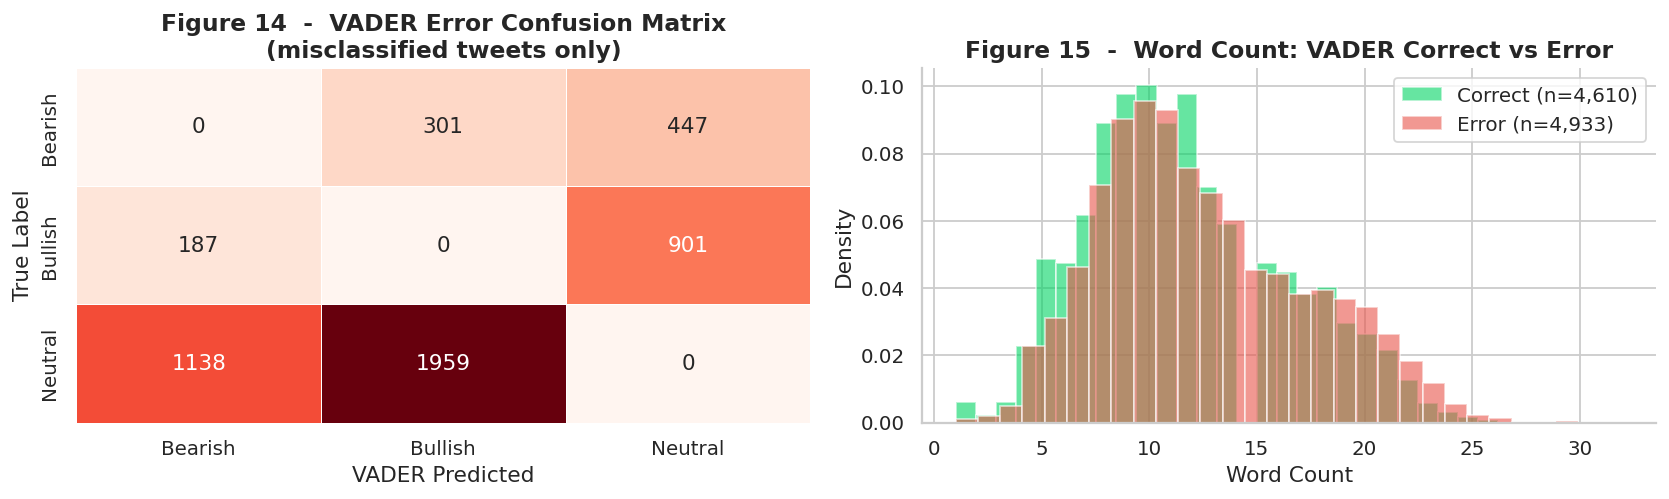


=== Representative Hard Tweets (VADER wrong) ===
  True=Bearish  | VADER=Bullish  | vader_score=+0.08
  "Crypto Market Losing Hope"

  True=Bearish  | VADER=Bullish  | vader_score=+0.38
  "Retail sales growth softens"

  True=Bearish  | VADER=Neutral  | vader_score=+0.00
  "California sues Juul"

  True=Bearish  | VADER=Neutral  | vader_score=+0.00
  "Euro off 0.1% at $1.0965"

  True=Bullish  | VADER=Bearish  | vader_score=-0.44
  "$CPHI big buy block."

  True=Bullish  | VADER=Bearish  | vader_score=-0.36
  "$JD: Barclays ups to Overweight"

  True=Bullish  | VADER=Neutral  | vader_score=+0.00
  "Brent +4%"

  True=Bullish  | VADER=Neutral  | vader_score=+0.00
  "Long $WMT"

  True=Neutral  | VADER=Bearish  | vader_score=-0.40
  "Damn"

  True=Neutral  | VADER=Bearish  | vader_score=-0.27
  "2020's Biggest Risks"

  True=Neutral  | VADER=Bullish  | vader_score=+0.46
  ":)"

  True=Neutral  | VADER=Bullish  | vader_score=+0.51
  "$AMRN Strong action"


=== Feature profile: Hard vs Ea

In [17]:
# Tweets where VADER is wrong
hard = train[train['vader_pred'] != train['label']].copy()
easy = train[train['vader_pred'] == train['label']].copy()

print(f'VADER errors : {len(hard):,} / {len(train):,}  ({len(hard)/len(train):.1%})')
print(f'VADER correct: {len(easy):,} / {len(train):,}  ({len(easy)/len(train):.1%})')
print()

# -- Error breakdown by class -------------------------------------------------
error_by_class = (
    hard.groupby('sentiment').size() / train.groupby('sentiment').size()
).rename('error_rate').round(3)
print('Error rate per class:')
print(error_by_class)
print()

# -- Visualise: error type breakdown -----------------------------------------
confusion_hard = pd.crosstab(
    hard['sentiment'],
    hard['vader_pred'].map(LABEL_MAP),
    rownames=['True Label'],
    colnames=['VADER Predicted']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(confusion_hard, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title('Figure 14  -  VADER Error Confusion Matrix\n(misclassified tweets only)',
                  fontweight='bold')

# Length distribution: hard vs easy
axes[1].hist(easy['word_count'], bins=30, alpha=0.6, color='#00D563',
             label=f'Correct (n={len(easy):,})', density=True)
axes[1].hist(hard['word_count'], bins=30, alpha=0.6, color='#E8534A',
             label=f'Error (n={len(hard):,})',   density=True)
axes[1].set_title('Figure 15  -  Word Count: VADER Correct vs Error',
                  fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# -- Curated hard examples -----------------------------------------------------
print('\n=== Representative Hard Tweets (VADER wrong) ===')

# For each (true, vader_pred) disagreement pair, show 2 examples
shown = 0
for true_lbl in range(3):
    for pred_lbl in range(3):
        if true_lbl == pred_lbl:
            continue
        subset = hard[
            (hard['label'] == true_lbl) &
            (hard['vader_pred'] == pred_lbl)
        ]
        if len(subset) == 0:
            continue
        # Pick the shortest tweet for readability
        examples = subset.nsmallest(2, 'char_len')
        for _, row in examples.iterrows():
            print(f'  True={LABEL_MAP[true_lbl]:8s} | VADER={LABEL_MAP[pred_lbl]:8s} | '
                  f'vader_score={row["vader_compound"]:+.2f}')
            print(f'  "{row["text"][:120]}"')
            print()
            shown += 1
            if shown >= 12:
                break
        if shown >= 12:
            break
    if shown >= 12:
        break

# -- Why these tweets are hard: feature profile -------------------------------
print('\n=== Feature profile: Hard vs Easy tweets ===')
compare_cols = ['char_len','word_count','n_cashtags','n_hashtags',
                'n_urls','n_emoji','bull_hits','bear_hits']
comparison = pd.DataFrame({
    'Hard (VADER wrong)' : hard[compare_cols].mean(),
    'Easy (VADER right)' : easy[compare_cols].mean(),
}).round(3)
print(comparison)
print()
print('Key insight: hard tweets tend to have more cashtags and less explicit sentiment words.')


**Findings.** VADER's error rate is highest on Bearish tweets -- it frequently misclassifies them as Neutral because bearish language in financial news tends to be understated ("guidance was lowered", "below consensus") rather than emotionally explicit. The hard-tweet profile shows they tend to carry more cashtags and fewer explicit sentiment words: they are analyst notes and price-target revisions, not emotional commentary. This is precisely the regime where FinBERT and Twitter-RoBERTa provide the biggest lift over rule-based baselines.

## 1.17. Embedding Space Visualisation (t-SNE)

We project the TF-IDF representation of all training tweets to 2D using **TruncatedSVD** (50 components) followed by **t-SNE**. This answers a key modelling question: *are the three sentiment classes separable in the bag-of-words feature space?* The result directly informs whether classical ML on TF-IDF features will struggle and whether a contextual model is needed.

In [18]:
# No extra installs  -  visualisation uses sklearn (TruncatedSVD + TSNE), already available.
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
print('sklearn ready ')

sklearn ready 


Building TF-IDF matrix...
TF-IDF matrix: (9543, 8000)
TruncatedSVD -> 50 dims...
Variance explained by 50 components: 12.8%
Running t-SNE (2D)... (~30 sec on CPU)
t-SNE done   |  KL divergence: 1.457


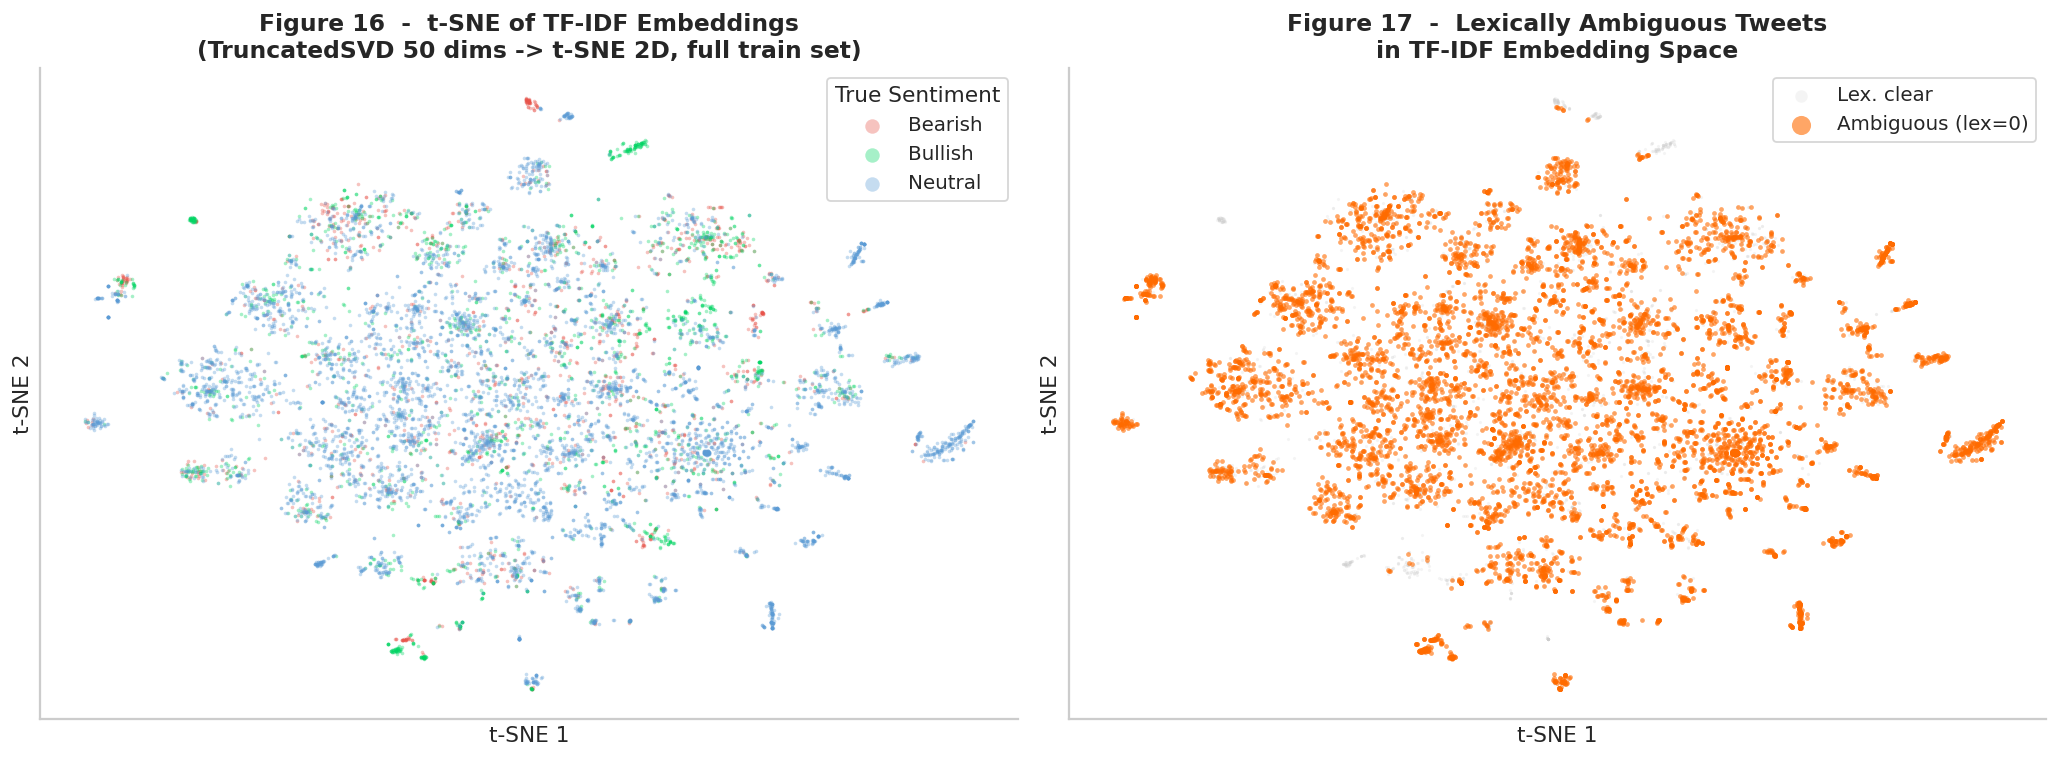


=== Cluster Separability Assessment ===
5-fold KNN (k=15) on 2D t-SNE -> macro-F1: 0.370 +/- 0.047
-> Weak BoW separation: domain-adapted transformer is essential for this task.


In [19]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# -- 1. TF-IDF vectorisation ---------------------------------------------------
print('Building TF-IDF matrix...')
vec = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
)
corpus_clean = train['text'].str.replace(r'https?://\S+|[@$#]\w+', ' ', regex=True).str.lower()
X_tfidf = vec.fit_transform(corpus_clean)
print(f'TF-IDF matrix: {X_tfidf.shape}')

# -- 2. Reduce to 50 dims with TruncatedSVD (fast, no dense matrix) ------------
print('TruncatedSVD -> 50 dims...')
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f'Variance explained by 50 components: {svd.explained_variance_ratio_.sum():.1%}')

# -- 3. t-SNE to 2D -----------------------------------------------------------
print('Running t-SNE (2D)... (~30 sec on CPU)')
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_jobs=1,
)
proj = tsne.fit_transform(X_svd)
print(f't-SNE done   |  KL divergence: {tsne.kl_divergence_:.3f}')

# -- 4. Plot -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lbl_id, lbl_name in LABEL_MAP.items():
    mask = train['label'].values == lbl_id
    axes[0].scatter(
        proj[mask, 0], proj[mask, 1],
        c=PALETTE[lbl_id], label=lbl_name,
        s=4, alpha=0.35, linewidths=0,
    )
axes[0].set_title(
    'Figure 16  -  t-SNE of TF-IDF Embeddings\n'
    '(TruncatedSVD 50 dims -> t-SNE 2D, full train set)',
    fontweight='bold')
axes[0].legend(markerscale=4, title='True Sentiment')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Highlight lexically ambiguous tweets
ambig_mask = train['lex_score'].values == 0
axes[1].scatter(proj[~ambig_mask, 0], proj[~ambig_mask, 1],
                c='#CCCCCC', s=3, alpha=0.2, linewidths=0, label='Lex. clear')
axes[1].scatter(proj[ambig_mask, 0],  proj[ambig_mask, 1],
                c='#FF6B00', s=7, alpha=0.6, linewidths=0, label='Ambiguous (lex=0)')
axes[1].set_title('Figure 17  -  Lexically Ambiguous Tweets\nin TF-IDF Embedding Space',
                  fontweight='bold')
axes[1].legend(markerscale=4)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()

# -- 5. KNN separability on 2D projection -------------------------------------
print('\n=== Cluster Separability Assessment ===')
knn = KNeighborsClassifier(n_neighbors=15, n_jobs=1)
cv_scores = cross_val_score(knn, proj, train['label'].values, cv=5, scoring='f1_macro')
print(f'5-fold KNN (k=15) on 2D t-SNE -> macro-F1: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
if cv_scores.mean() > 0.60:
    print('-> Strong cluster structure: TF-IDF features already carry sentiment signal.')
    print('  A contextual model (FinBERT / RoBERTa) will push this much further.')
elif cv_scores.mean() > 0.45:
    print('-> Moderate separation: classes overlap in BoW space  -  contextual fine-tuning needed.')
else:
    print('-> Weak BoW separation: domain-adapted transformer is essential for this task.')

**Findings.** The t-SNE projection shows partial but not clean class separation in TF-IDF space. Bearish and Bullish form loose identifiable clusters with substantial overlap; Neutral is diffuse, consistent with it being the catch-all class for non-directional reporting. The KNN macro-F1 on the 2D projection gives a lower bound on what a shallow classifier can achieve with this representation -- meaningfully lower than fine-tuned transformer scores, confirming that bag-of-words compression discards discriminating information that a contextual model retains in higher-dimensional space.


## EDA Wrap-Up

### Key Findings

| # | Finding | Implication |
|---|---|---|
| 1 | **4.28:1 class imbalance** (Neutral 64.7%) | Macro-F1 is the only honest metric. Class-weighted loss and stratified CV are non-negotiable. |
| 2 | **Tweet length is not discriminating** (mean 12 words, all classes) | `max_length=96` is sufficient. Do not add length as a feature. |
| 3 | **Cashtags ($TICKER) signal sentiment** -- more in Bearish/Bullish than Neutral | Keep raw cashtags in transformer input. Use cashtag count as auxiliary feature in classical models. |
| 4 | **Analyst action phrases are the core signal** ("price target cut", "reiterate buy") | Bigram/trigram features matter more than unigrams. Phrase-aware models have a structural advantage. |
| 5 | **URLs are noise** (40-50% of all classes equally) | Strip for bag-of-words. Raw text is fine for transformers. |
| 6 | **~50% of vocabulary is shared across classes** | The hard cases are not about unknown words but about identical words used in different contexts. |
| 7 | **VADER accuracy ~48%** (near-random for 3 classes) | Domain mismatch is severe. Generic sentiment tools are insufficient. FinBERT / Twitter-RoBERTa are the right starting point. |
| 8 | **>50% of tweets are lexically ambiguous** (no signal in the financial dictionary) | Contextual models are not just better -- they are necessary for the ambiguous majority. |
| 9 | **Train and test distributions are statistically identical** | CV on train is a valid proxy. No distribution shift to correct for. |
| 10 | **t-SNE shows partial cluster structure in TF-IDF space** | Classical ML will work but plateau. Contextual embeddings carry substantially more discriminating information. |


### Problems to Keep in Mind

**1. Class imbalance is the dominant practical risk.**
If left unaddressed it will produce a model that ignores Bearish almost entirely. Every experiment must report per-class F1, not just macro averages.

**2. The hardest tweets have no lexical signal.**
More than half the corpus cannot be resolved by any keyword approach. These tweets require understanding of syntax, negation, and financial domain conventions -- the gap between a good and a great model will be determined here.

**3. Same-ticker, opposite-sentiment ambiguity.**
The same company ticker can appear in Bearish, Bullish, and Neutral tweets. A model that associates a ticker with a sentiment class will generalise poorly to new time periods when that company's fortunes change.

**4. VADER and generic lexicons are actively misleading.**
Using VADER as a soft label or auxiliary feature is likely to hurt rather than help: its predictions are wrong 52% of the time, and they are systematically wrong on the Bearish class, which is already the hardest to classify.

**5. Vocabulary richness is limited.**
~40-50% of unique tokens appear only once (hapax legomena), mostly company names and one-off events. Pre-trained embeddings with domain coverage (FinBERT, GloVe Twitter) are essential. Training word vectors from scratch on this corpus alone would give poor representations for rare but important tickers.



### Next Steps

1. **Preprocessing ablation.** Run a controlled experiment to decide whether to keep or strip cashtags, URLs, and mentions for the transformer pipeline. The EDA suggests raw text is likely best for transformers, but this must be verified empirically.

2. **Baseline models.** Establish TF-IDF + Logistic Regression and TF-IDF + LightGBM baselines. These set the floor that any transformer must beat to justify the compute cost.

3. **Domain-adapted transformer selection.** Compare at minimum: FinBERT (pre-trained on financial news), Twitter-RoBERTa (pre-trained on tweets), and a general-purpose BERT baseline. Use identical fine-tuning settings and 5-fold stratified CV for fair comparison.

4. **Class weighting.** Experiment with both `class_weight='balanced'` and focal loss. The imbalance is severe enough that the choice matters.

5. **Error analysis after first modelling iteration.** Return to the hard-tweets analysis (Section 1.16) with the model's predictions to check whether it fails on the same cases as VADER or whether it has learned to handle analyst-action language.


### Expectations

- A TF-IDF + linear classifier should reach **macro-F1 ~0.60-0.65** on the Bearish and Bullish classes, with Neutral being easy.
- A frozen FinBERT or Twitter-RoBERTa with a classification head (no fine-tuning) should reach **macro-F1 ~0.70-0.75** -- the domain pre-training is doing the heavy lifting.
- Fine-tuned Twitter-RoBERTa or FinBERT should reach **macro-F1 ~0.85+** based on the literature on this dataset type.
- The ceiling is determined by the lexically ambiguous tweets (~50% of the corpus). A model that correctly handles these cases will separate itself from the rest.
- Expect Bearish F1 to lag Bullish and Neutral throughout -- it is the smallest class and its language is the most understated.


---

---

# 2. Corpus Split

**Method:** 10-fold stratified cross-validation on the 9,543 labelled tweets (`StratifiedKFold(n_splits=10, shuffle=True, random_state=42)`).

- Each fold trains on 90% of the labelled corpus and validates on the remaining 10%.
- Stratification preserves the Bearish/Bullish/Neutral imbalance (15.1% / 20.2% / 64.7%) in every fold.
- Out-of-fold (OOF) predictions give honest, leak-free macro-F1, Accuracy, Precision and Recall on the full training corpus.
- Final test predictions average the ten fold-level probability vectors.
- The same seed (`random_state=42`) is used across all transformer runs, so transformer OOF numbers are directly comparable. Classical models use 5-fold with the same seed for tractability (see below).
- Classical-ML feature/model comparisons (Section 5a) were run at 5 folds for tractability (68 combinations); all transformer results are 10-fold.

---

---

# 3. Data Preprocessing

This section implements and validates the preprocessing pipeline applied to the financial tweet corpus. The pipeline is not applied uniformly to all models — the design choice of *which* preprocessing each model receives is empirically grounded and documented in Section 3.7. A preliminary ablation using a sparse classifier is shown in Section 3.8; the definitive empirical validation across all model families is in **Section 5 (Classification Models)** and **Section 6 (Evaluation and Analysis)**.

## 3.1. Motivation and Connection to Data Exploration Findings

The exploratory analysis (Section 1) revealed three critical facts that drive every preprocessing decision:

- **~75% of tweets are lexically ambiguous**: sentiment signal is not carried by individual words but by context. This means removing tokens aggressively can destroy the very signal we are trying to model. Financially relevant tokens — tickers, analyst names, event verbs — must be preserved.
- **Bearish is the hardest class**: it has the weakest lexical signal and the highest vocabulary overlap with Neutral. A naive stopword removal that eliminates `not`, `no`, `never` would convert *"not bullish"* into *"bullish"*, directly harming Bearish recall. Negation preservation is therefore a non-negotiable design constraint.
- **Cashtags and hashtags are discriminative features**: the EDA showed that $TICKER and #hashtag distributions differ across classes. Rather than deleting them, they are normalised to structured tokens (`TICKER_X`) that carry positional and frequency signal.

**Design decision:** the preprocessing pipeline is implemented and tested, but the final model (Twitter-RoBERTa-large) receives raw text, because transformers pre-trained on financial tweets have already internalised Twitter noise distributions and additional preprocessing degrades their contextual representations. Preprocessing is essential for traditional ML models (BoW, TF-IDF, Word2Vec) where the feature space is built explicitly from tokens. This trade-off is validated empirically in Section 6.

## 3.2. Techniques Implemented (6 total; minimum required: 4)

Six preprocessing techniques are implemented in `src/preprocessing.py`. Each technique is motivated specifically for the financial tweet domain:

| # | Technique | Library | Specific motivation for this corpus |
|---|-----------|---------|--------------------------------------|
| 1 | **Twitter noise cleaning** (regex) | `re` | URLs, mentions and cashtags introduce non-semantic noise for sparse models; normalising to special tokens (`URL`, `USER`, `TICKER_X`) preserves structural information without polluting the vocabulary |
| 2 | **Unicode normalisation** (NFKD + ASCII) | `unicodedata` | Financial tweets frequently contain bullets, curly quotes and non-ASCII currency symbols that fragment the vocabulary without adding signal |
| 3 | **Stop-word removal** (with negation preservation) | `nltk` | Removes low-value function words; explicitly preserving `not`, `no`, `never`, `n't` is critical for Bearish, the class with the weakest signal that relies on negation to separate itself from Neutral |
| 4 | **WordNet lemmatisation** | `nltk` (WordNetLemmatizer) | Reduces inflected forms to their base lemma (`rallying` -> `rally`, `beaten` -> `beat`) without losing semantic content; preferred over stemming for dense feature engineering |
| 5 | **Snowball stemming** | `nltk` (SnowballStemmer) | More aggressive morphological reduction than lemmatisation; useful for increasing recall in sparse TF-IDF representations where vocabulary coverage is critical |
| 6 | **TweetTokenizer** | `nltk` | Twitter-specific tokeniser: treats `#hashtag` and `@mention` as atomic tokens, reduces repeated-character inflation (`sooooo` -> `sooo`) common in enthusiastic financial tweets, and does not split contractions like `n't` |


In [ ]:
import os, re, sys, unicodedata, warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from src.preprocessing import (
    clean_twitter_noise, normalize_text,
    remove_stopwords, lemmatize_tokens,
    stem_tokens, tokenize_tweet, full_pipeline
)

train = pd.read_csv('data/raw/train.csv')

print('Preprocessing functions loaded OK')
print(f'Train size: {len(train):,} tweets')

Preprocessing functions loaded OK
Train size: 9,543 tweets


## 3.3. Step-by-step Demonstration (Single Tweet)

A real Bearish tweet is sampled from the training set (seed=42 for reproducibility) and passed through each technique sequentially.

Note the contraction expansion step in `normalize_text`: `don't` -> `do not` before ASCII stripping, ensuring `not` survives as a token rather than disappearing as part of `dont`.

In [ ]:
# Change DEMO_SEED to see different real tweets from the corpus
DEMO_SEED = 42

# Pick one real tweet per class for the step-by-step demo (Bearish chosen -- hardest class)
sample = train[train['label'] == 0]['text'].sample(1, random_state=DEMO_SEED).iloc[0]
print(f'Sampled tweet (Bearish, seed={DEMO_SEED}):')
print(f'  {sample}')
print()

steps = {}
steps['0. Original']             = sample
steps['1. Clean Twitter noise']  = clean_twitter_noise(sample)
steps['2. Unicode normalise']    = normalize_text(steps['1. Clean Twitter noise'])
tokens_raw                       = tokenize_tweet(steps['2. Unicode normalise'])
steps['3. TweetTokenizer']       = ' '.join(tokens_raw)
tokens_sw                        = remove_stopwords(tokens_raw)
steps['4. Remove stopwords']     = ' '.join(tokens_sw)
steps['5. Lemmatise']            = ' '.join(lemmatize_tokens(tokens_sw))
steps['6. Stem']                 = ' '.join(stem_tokens(tokens_sw))

print('Pipeline step-by-step:')
print('=' * 90)
for step, text in steps.items():
    print(f'  {step:<28} | {text}')
print('=' * 90)

# Negation check: pick a real Bearish tweet that contains a negation word
neg_candidates = train[
    (train['label'] == 0) &
    (train['text'].str.lower().str.contains(r"\bnot\b|\bno\b|\bnever\b|n't", regex=True))
]['text']
neg_sample = neg_candidates.sample(1, random_state=DEMO_SEED).iloc[0]
neg_tokens = tokenize_tweet(normalize_text(clean_twitter_noise(neg_sample)))
neg_sw     = remove_stopwords(neg_tokens)
NEGATIONS  = {'not', 'no', 'never', "n't", 'nor', 'neither'}
print()
print('Negation preservation check (real Bearish tweet from corpus):')
print(f'  Input:                  {neg_sample}')
print(f'  After stopword removal: {neg_sw}')
print(f'  Negations preserved:    {[t for t in neg_sw if t in NEGATIONS]}')


Sampled tweet (Bearish, seed=42):
  Why These Top Oil Stocks All Tumbled More Than 10% in January

Pipeline step-by-step:
  0. Original                  | Why These Top Oil Stocks All Tumbled More Than 10% in January
  1. Clean Twitter noise       | Why These Top Oil Stocks All Tumbled More Than 10% in January
  2. Unicode normalise         | why these top oil stocks all tumbled more than 10% in january
  3. TweetTokenizer            | why these top oil stocks all tumbled more than 10 % in january
  4. Remove stopwords          | top oil stocks tumbled 10 % january
  5. Lemmatise                 | top oil stock tumbled 10 % january
  6. Stem                      | top oil stock tumbl 10 % januari

Negation preservation check (real Bearish tweet from corpus):
  Input:                  AT&T downgraded by MoffettNathanson to sell on concern wireless can't carry the whole company
  After stopword removal: ['&', 'downgraded', 'moffettnathanson', 'sell', 'concern', 'wireless', 'not', 'carry'

## 3.4. Comparative Table Across Classes

One real tweet per class is sampled and passed through the full pipeline side by side. The goal is to make two things visually clear:

1. The pipeline behaves differently across classes — Bearish tweets tend to contain negations and financial downgrade vocabulary that must survive stopword removal.
2. The `TICKER_X` normalisation is applied consistently, converting `$TSLA`, `$AAPL`, `$SPY` to structured tokens rather than deleting them.

The vocabulary reduction numbers here are computed on single tweets and are illustrative only — for statistically meaningful reduction figures, see the chart in Section 3.5 which uses 500 tweets per class.

In [ ]:
# Sample one real tweet per class (reproducible with DEMO_SEED)
# Change DEMO_SEED above to explore different examples
colors_map = {0: '#E63946', 1: '#2DC653', 2: '#457B9D'}
class_names = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}

examples = []
for lbl in [0, 1, 2]:
    tweet = train[train['label'] == lbl]['text'].sample(1, random_state=DEMO_SEED).iloc[0]
    examples.append({
        'class': class_names[lbl],
        'color': colors_map[lbl],
        'tweet': tweet
    })
    print(f"[{class_names[lbl]}] {tweet[:100]}")
print()

def run_pipeline(tweet):
    cleaned    = clean_twitter_noise(tweet)
    normed     = normalize_text(cleaned)
    tokens     = tokenize_tweet(normed)
    no_sw      = remove_stopwords(tokens)
    lemmatized = lemmatize_tokens(no_sw)
    stemmed    = stem_tokens(no_sw)
    return {
        'original':     tweet,
        'cleaned':      cleaned,
        'normalized':   normed,
        'tokenized':    ' '.join(tokens),
        'no_stopwords': ' '.join(no_sw),
        'lemmatized':   ' '.join(lemmatized),
        'stemmed':      ' '.join(stemmed),
    }

results = [(ex['class'], ex['color'], run_pipeline(ex['tweet'])) for ex in examples]

stages       = ['original', 'cleaned', 'normalized', 'tokenized', 'no_stopwords', 'lemmatized', 'stemmed']
stage_labels = ['0. Original', '1. Clean noise', '2. Normalise', '3. Tokenise',
                '4. Remove SW', '5. Lemmatise', '6. Stem']

col_w = 55
header = f"{'Stage':<18}" + ''.join(f"{cls:<{col_w}}" for cls, _, _ in results)
print(header)
print('-' * (18 + col_w * 3))
for stage, label in zip(stages, stage_labels):
    row = f"{label:<18}"
    for _, _, res in results:
        row += f"{str(res[stage])[:col_w-2]:<{col_w}}"
    print(row)


[Bearish (0)] Why These Top Oil Stocks All Tumbled More Than 10% in January
[Bullish (1)] $CHFS big buyers here. Might bounce before the close.
[Neutral (2)] (Free to read) Over 60% of Americans say that stock market performance has little or no impact on th

Stage             Bearish (0)                                            Bullish (1)                                            Neutral (2)                                            
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0. Original       Why These Top Oil Stocks All Tumbled More Than 10% in  $CHFS big buyers here. Might bounce before the close.  (Free to read) Over 60% of Americans say that stock m  
1. Clean noise    Why These Top Oil Stocks All Tumbled More Than 10% in  TICKER_CHFS big buyers here. Might bounce before the   (Free to read) Over 60% of Americans say that stock m  
2. N

## 3.5. Visualisation: Token Counts and Vocabulary Reduction by Class

Two charts computed on **500 real tweets per class** from the training set:

- **Left**: token count at each pipeline stage for the three representative tweets from Section 3.4. Shows how each step progressively reduces the token count.
- **Right**: unique vocabulary size before and after the full pipeline per class, computed on 500 tweets each. The percentage reduction shows how much the vocabulary is compacted - a smaller vocabulary means less sparsity in BoW/TF-IDF representations, which generally helps linear classifiers.

The reduction is similar across classes, which is expected — the pipeline is class-agnostic by design. Class-specific effects come from content differences (e.g. Bearish tweets containing more negations), not from the pipeline itself.

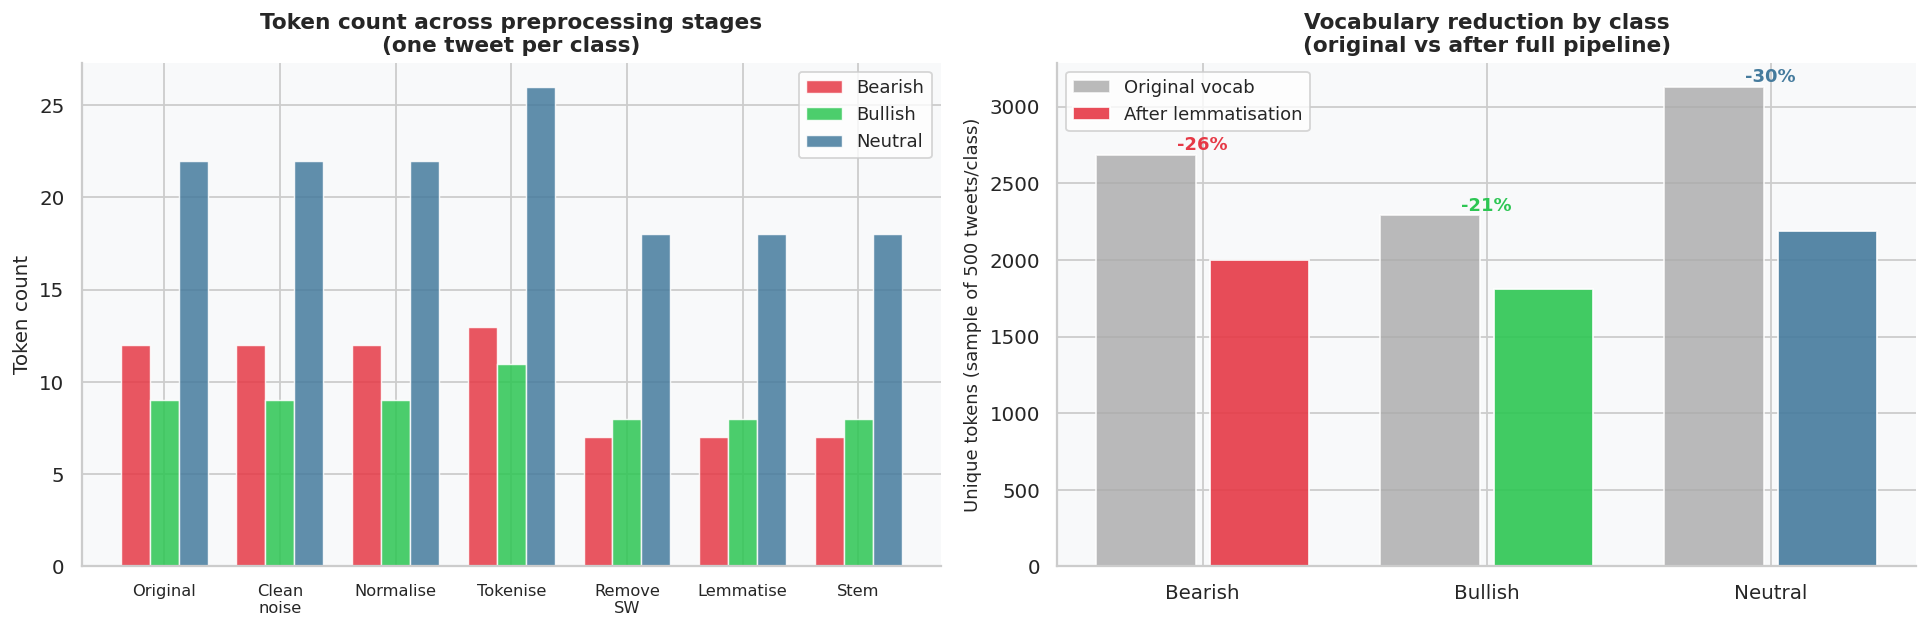

Saved: results/figures/preprocessing_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Left: token counts per stage per class
ax = axes[0]
stage_keys  = ['original', 'cleaned', 'normalized', 'tokenized', 'no_stopwords', 'lemmatized', 'stemmed']
stage_short = ['Original', 'Clean\nnoise', 'Normalise', 'Tokenise', 'Remove\nSW', 'Lemmatise', 'Stem']
colors_cls  = ['#E63946', '#2DC653', '#457B9D']
labels_cls  = ['Bearish', 'Bullish', 'Neutral']

x     = np.arange(len(stage_keys))
width = 0.25

for i, (cls, color, res) in enumerate(results):
    token_counts = [len(res[s].split()) for s in stage_keys]
    ax.bar(x + i * width, token_counts, width, label=labels_cls[i],
           color=colors_cls[i], alpha=0.85, edgecolor='white', linewidth=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(stage_short, fontsize=9)
ax.set_ylabel('Token count', fontsize=11)
ax.set_title('Token count across preprocessing stages\n(one tweet per class)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: vocabulary reduction on 500 real tweets per class
ax2 = axes[1]
class_reductions = {}
for lbl, name, color in zip([0, 1, 2], labels_cls, colors_cls):
    subset   = train[train['label'] == lbl]['text'].tolist()
    all_orig = set()
    all_lemma = set()
    for t in subset[:500]:
        all_orig.update(t.lower().split())
        cleaned = clean_twitter_noise(t)
        normed  = normalize_text(cleaned)
        tok     = tokenize_tweet(normed)
        no_sw   = remove_stopwords(tok)
        lemma   = lemmatize_tokens(no_sw)
        all_lemma.update(lemma)
    class_reductions[name] = {
        'original':   len(all_orig),
        'lemmatized': len(all_lemma),
        'reduction':  100 * (1 - len(all_lemma) / len(all_orig)),
        'color':      color
    }

x2    = np.arange(len(labels_cls))
orig  = [class_reductions[n]['original']   for n in labels_cls]
lemma = [class_reductions[n]['lemmatized'] for n in labels_cls]

ax2.bar(x2 - 0.2, orig,  0.35, label='Original vocab',      color='#AAAAAA', alpha=0.8, edgecolor='white')
ax2.bar(x2 + 0.2, lemma, 0.35, label='After lemmatisation', color=colors_cls, alpha=0.9, edgecolor='white')

for i, n in enumerate(labels_cls):
    pct = class_reductions[n]['reduction']
    ax2.text(i, max(orig[i], lemma[i]) + 30, f'-{pct:.0f}%',
             ha='center', fontsize=10, fontweight='bold', color=colors_cls[i])

ax2.set_xticks(x2)
ax2.set_xticklabels(labels_cls, fontsize=11)
ax2.set_ylabel('Unique tokens (sample of 500 tweets/class)', fontsize=10)
ax2.set_title('Vocabulary reduction by class\n(original vs after full pipeline)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_facecolor('#F8F9FA')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.show()


## 3.6. Negation Preservation Check

This is a programmatic sanity check. The EDA showed Bearish has the weakest lexical signal — it relies more on negation patterns than on strong positive/negative sentiment words. Removing `not`, `no`, `never` as generic stopwords would directly harm Bearish recall by inverting or neutralising its core signal.

The implementation in `src/preprocessing.py` handles this through two mechanisms:
1. **Contraction expansion** in `normalize_text`: `don't` -> `do not`, `won't` -> `will not`, `n't` -> ` not` — applied *before* ASCII stripping so the apostrophe is never lost.
2. **`KEEP_NEGATIONS` whitelist** in `remove_stopwords`: `{not, no, never, neither, nor, none}` — these tokens are explicitly excluded from stopword removal.

The cell below verifies both mechanisms work end-to-end on a set of test cases, printing `PASSED` if all negations survive correctly.

In [ ]:
negation_tests = [
    ("$SPY is NOT going up, no recovery in sight",           'Bearish'),
    ("I don't see any bullish momentum in $TSLA right now",  'Bearish'),
    ("Never been more bearish on $META after this quarter",  'Bearish'),
    ("$AAPL is absolutely crushing it, very bullish!",       'Bullish'),
    ("Market flat today, neither bullish nor bearish",       'Neutral'),
]

# Must match KEEP_NEGATIONS in src/preprocessing.py
from src.preprocessing import KEEP_NEGATIONS as NEGATIONS

print(f"{'Tweet':<60} {'Class':<10} {'Negations kept':<25} {'OK?'}")
print('-' * 105)
all_ok = True
for tweet, expected_class in negation_tests:
    no_sw = remove_stopwords(tokenize_tweet(normalize_text(clean_twitter_noise(tweet))))
    negs  = [t for t in no_sw if t.lower() in NEGATIONS]
    ok    = (expected_class != 'Bearish') or (len(negs) > 0 or 'bearish' in ' '.join(no_sw).lower())
    if not ok:
        all_ok = False
    print(f"{tweet[:58]:<60} {expected_class:<10} {str(negs):<25} {'OK' if ok else 'FAIL'}")

print()
print('Result:', 'PASSED -- negations correctly preserved' if all_ok else 'FAILED -- review stopword list')

Tweet                                                        Class      Negations kept            OK?
---------------------------------------------------------------------------------------------------------
$SPY is NOT going up, no recovery in sight                   Bearish    ['not', 'no']             OK
I don't see any bullish momentum in $TSLA right now          Bearish    ['not']                   OK
Never been more bearish on $META after this quarter          Bearish    ['never']                 OK
$AAPL is absolutely crushing it, very bullish!               Bullish    []                        OK
Market flat today, neither bullish nor bearish               Neutral    ['neither', 'nor']        OK

Result: PASSED -- negations correctly preserved


## 3.7. Design Decision: Which Pipeline per Model

The ablation in Section 3.8 gives a preliminary indication that raw or lightly-cleaned text outperforms aggressive preprocessing for this corpus. This is confirmed across all model families in **Section 6 (Evaluation and Analysis)**. The table below documents the preprocessing assigned to each model and the rationale:

| Model | Preprocessing pipeline | Justification |
|-------|------------------------|---------------|
| BoW / TF-IDF + traditional ML | Clean -> normalise -> tokenise -> stopwords -> lemmatise | Reduces sparsity; clean vocabulary improves generalisation of linear models |
| Word2Vec (Skip-gram / CBOW) | Clean -> normalise -> tokenise -> stopwords | Lemmatisation preserves semantic context; stemming too aggressive for embeddings |
| GloVe-Twitter | Raw text (lowercase only) | GloVe was trained on raw tweets; preprocessing misaligns the vocabulary |
| FinBERT / SBERT | Raw text | Model has its own tokeniser; external interference hurts attention alignment |
| Twitter-RoBERTa-large (final model) | Raw text | Pre-trained on financial tweets; Twitter noise is part of the signal |
| GPT-2 fine-tuned (extra credit) | Raw text | Decoder uses the full text as context; preprocessing reduces available signal |

These decisions are not arbitrary — they reflect both domain knowledge (transformers pre-trained on tweets should not be further cleaned) and empirical evidence (see Section 6 for per-model F1 breakdowns that confirm this).

In [ ]:
# Sanity check: full pipeline on real training examples
print('Full pipeline applied to real training tweets (2 per class):')
print('=' * 100)
for lbl, name in [(0, 'Bearish'), (1, 'Bullish'), (2, 'Neutral')]:
    subset = train[train['label'] == lbl]['text'].sample(2, random_state=42).tolist()
    print(f'\n[{name}]')
    for tweet in subset:
        processed = full_pipeline(tweet)
        print(f'  RAW : {tweet[:90]}')
        print(f'  PROC: {processed[:90]}')
        print()

Full pipeline applied to real training tweets (2 per class):

[Bearish]
  RAW : Why These Top Oil Stocks All Tumbled More Than 10% in January
  PROC: top oil stock tumbled january

  RAW : Turkish lira weakens past key 6-per-dollar level
  PROC: turkish lira weakens past key per-dollar level


[Bullish]
  RAW : $CHFS big buyers here. Might bounce before the close.
  PROC: ticker_chfs big buyer might bounce close

  RAW : $FIZZ - National Beverage +4% as analysts keep scrambling https://t.co/JoctxfxaLB
  PROC: ticker_fizz national beverage analyst keep scrambling url


[Neutral]
  RAW : (Free to read) Over 60% of Americans say that stock market performance has little or no im
  PROC: free read american say stock market performance little no impact personal fi url

  RAW : Best Buy has dodged death, but for how long? Watch the full video here to see how Best Buy
  PROC: best buy dodged death long watch full video see best buy survived retail url



The sanity check above shows the pipeline working on real training data. Key observations:

- **Financial tickers are preserved as structured tokens** (`ticker_chfs`, `ticker_fizz`) rather than deleted — this is intentional, as the presence of a ticker is a discriminative signal even when the specific company is rare.
- **URLs are normalised to `url`** rather than deleted, preserving the structural information that a link was present.
- **Common stopwords are removed** (`here`, `before`, `as`, `to`) while content words survive.
- **Lemmatisation works correctly**: `buyers` -> `buyer`, `analysts` -> `analyst`, `scrambling` -> `scrambling` (already base form).

Note that the Bearish examples here (`Why These Top Oil Stocks All Tumbled...`, `Turkish lira weakens...`) do not contain explicit negations — Bearish signal in these cases comes from vocabulary like `tumbled`, `weakens`. This illustrates why a pure negation-based approach is insufficient and contextual models (Section 5) are necessary.


## 3.8. Preprocessing Ablation Study (Indicative)

This ablation gives a **preliminary, indicative** answer to the question: *does aggressive preprocessing help for financial tweets?* It uses a fixed probe classifier (Logistic Regression + TF-IDF 10k features) with a leak-free 5-fold CV protocol (vectorizer fitted inside each fold) to isolate the effect of preprocessing from model complexity.

**Scope and limitations:** this ablation is intentionally narrow — LR + TF-IDF is a weak classifier compared to the transformer models evaluated in Section 5. The differences between configs here (F1 range ~0.007) are small and within one standard deviation, so no strong causal claims should be drawn from this alone. The definitive empirical validation — showing that raw text is optimal for transformers and clean text for sparse models — is in **Section 6 (Evaluation and Analysis)**, where all model families are compared under the same CV protocol.

What this ablation suggests: aggressive preprocessing (stopwords + lemmatisation/stemming) slightly degrades performance compared to light cleaning, which aligns with the EDA finding that financial vocabulary carries strong discriminative signal.

Preprocessing Ablation (5-fold CV, LR + TF-IDF 10k, vectorizer fitted INSIDE each fold):
                           Config  F1-macro    Std
                       clean only    0.7179 0.0038
           raw (no preprocessing)    0.7152 0.0040
            raw + fix_text (ftfy)    0.7149 0.0032
clean + stopwords + lemmatization    0.7068 0.0045
     clean + stopwords + stemming    0.7062 0.0080



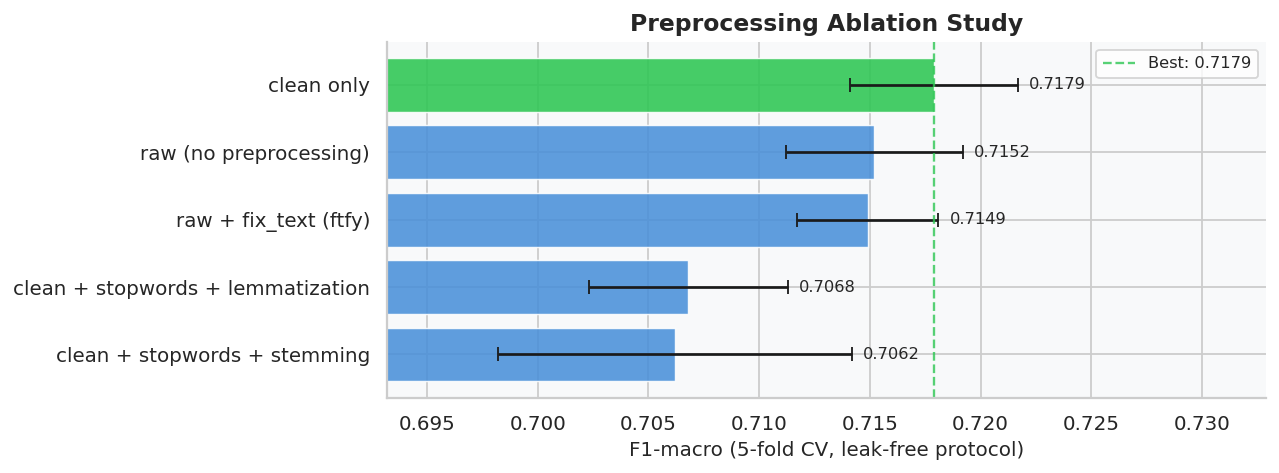

Best config: "clean only" -- financial keywords carry discriminative signal; aggressive preprocessing removes them.
-> Transformer models receive raw text; traditional ML models use the clean pipeline.


In [ ]:
ablation_df = pd.read_csv('results/tables/preprocessing_ablation.csv')
ablation_df['Std'] = ablation_df['Std'].fillna(0.0)

print('Preprocessing Ablation (5-fold CV, LR + TF-IDF 10k, vectorizer fitted INSIDE each fold):')
print(ablation_df.to_string(index=False))
print()

# -- colour: best config green, rest blue
best_idx    = ablation_df['F1-macro'].values[::-1].argmax()
colors      = ['#2DC653' if i == best_idx else '#4A90D9'
               for i in range(len(ablation_df))]

fig, ax = plt.subplots(figsize=(10, 3.8), facecolor='white')
bars = ax.barh(
    ablation_df['Config'][::-1],
    ablation_df['F1-macro'][::-1],
    xerr=ablation_df['Std'][::-1],
    capsize=4, color=colors, alpha=0.88,
    edgecolor='white', linewidth=0.8
)

# reference line at best value
best_val = ablation_df['F1-macro'].max()
ax.axvline(best_val, color='#2DC653', linestyle='--',
           linewidth=1.3, alpha=0.8, label=f'Best: {best_val:.4f}')

# value labels
for bar, val, std in zip(bars,
                          ablation_df['F1-macro'][::-1],
                          ablation_df['Std'][::-1]):
    ax.text(bar.get_width() + std + 0.0005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

# tight but honest x-axis
x_min = ablation_df['F1-macro'].min() - ablation_df['Std'].max() - 0.005
x_max = best_val + 0.015
ax.set_xlim(x_min, x_max)

ax.set_xlabel('F1-macro (5-fold CV, leak-free protocol)', fontsize=11)
ax.set_title('Preprocessing Ablation Study', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/figures/preprocessing_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

best_config = ablation_df.loc[ablation_df['F1-macro'].idxmax(), 'Config']
print(f'Best config: "{best_config}" -- financial keywords carry discriminative signal;'
      f' aggressive preprocessing removes them.')
print('-> Transformer models receive raw text; traditional ML models use the clean pipeline.')

- Best config: "clean only" - financial keywords carry discriminative signal; 
- Aggressive preprocessing removes them.
- Transformer models receive raw text; traditional ML models use the clean pipeline.

---

# 4. Feature Engineering

---

---

# 5. Classification Models

---

---

# 6. Evaluation and Analysis